# Class Imbalance Analysis: Experiment 3

**Objective**: Analyze how method performance degrades as class imbalance increases (minority proportion decreases).

---

## Overview

**Experiment 3** evaluates performance degradation across varying levels of class imbalance:
1. Tests methods at multiple minority proportions (from balanced to highly imbalanced)
2. Uses **NO HPO** (default parameters only) to isolate the effect of class imbalance
3. All metrics are **averaged across CV folds** per dataset-method-minority_proportion combination

This notebook is structured as follows (PD only):
- **Part 1: General Statistics & Averaged Graphs** - Degradation stats, smoothed trend lines, Foundation vs Baselines comparison
- **Part 2: Rank Analysis** - Rank evolution, Spearman rank correlation, Pearson performance correlation
- **Part 3: Per-Dataset Analysis** - Individual dataset imbalance curves

---

## 1. Setup & Configuration

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pickle

# =============================================================================
# SETUP PATHS (Notebook is in notebooks/ folder)
# =============================================================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # notebooks/ -> project root
sys.path.insert(0, str(PROJECT_ROOT))

# Import foundation methods list from method config
from src.methods.method_config import FOUNDATION_METHODS

EXPERIMENT_NAME = "experiment3"
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT_NAME
SUMMARY_DIR = RESULTS_DIR / "summary"
FIGURES_DIR = PROJECT_ROOT / "figures" / "experiment3" / "pd"

# Load config to get expected minority proportions
from src.utils.config_reader import load_config

print("=" * 80)
print("  EXPERIMENT 3 POST-ANALYSIS: CLASS IMBALANCE ANALYSIS")
print("=" * 80)
print(f"Project root:       {PROJECT_ROOT}")
print(f"Results directory:  {RESULTS_DIR}")
print(f"Summary directory:  {SUMMARY_DIR}")
print(f"Figures directory:  {FIGURES_DIR}")

# =============================================================================
# LOAD CONFIG AND CHECK COMPLETENESS
# =============================================================================

try:
    config = load_config("Experiment3")
    imb_config = config.get("imbalance", {})
    minority_proportion_max = imb_config.get("minority_proportion_max", 0.5)
    minority_proportion_min = imb_config.get("minority_proportion_min", 0.01)
    minority_proportion_step = imb_config.get("minority_proportion_step", 0.01)
    
    # Generate expected minority proportions
    expected_proportions = []
    current = minority_proportion_max
    while current >= minority_proportion_min - 1e-9:
        expected_proportions.append(round(current, 4))
        current -= minority_proportion_step
    if expected_proportions[-1] != minority_proportion_min:
        expected_proportions.append(minority_proportion_min)
    
    print(f"\nExpected minority proportions from config:")
    print(f"  minority_proportion_max={minority_proportion_max}, minority_proportion_min={minority_proportion_min}, minority_proportion_step={minority_proportion_step}")
    print(f"  {len(expected_proportions)} proportions: {expected_proportions[0]} -> {expected_proportions[-1]}")
    
    # Get expected datasets and methods (PD only)
    pd_datasets = list(config.get("datasets", {}).get("pd", {}).keys())
    pd_methods = list(config.get("methods", {}).get("pd", {}).keys())
    
    print(f"\nExpected PD datasets: {len(pd_datasets)}")
    print(f"Expected PD methods: {len(pd_methods)}")
    
except Exception as e:
    print(f"\n[WARNING] Could not load config: {e}")
    expected_proportions = None
    pd_datasets = []
    pd_methods = []

# =============================================================================
# CHECK RESULT COMPLETENESS
# =============================================================================
#
# Result file structure for Experiment3:
#   - Results stored as: {results_dir}/pd/{dataset}.pkl
#   - Each .pkl contains: results[minority_proportion][method] = fold_results
#
# =============================================================================

def check_result_completeness(results_dir: Path, task_type: str, expected_datasets: list,
                               expected_methods: list, expected_proportions: list):
    """
    Check which dataset-method-minority_proportion combinations are missing results.
    
    Reads each {dataset}.pkl file and checks the nested structure:
        results[minority_proportion][method] = fold_results
    """
    results_subdir = results_dir / task_type
    
    if not results_subdir.exists():
        print(f"[WARNING] Results directory not found: {results_subdir}")
        return {}, 0, len(expected_datasets) * len(expected_methods) * len(expected_proportions)
    
    missing_results = {}
    complete_count = 0
    total_expected = len(expected_datasets) * len(expected_methods) * len(expected_proportions)
    
    for dataset in expected_datasets:
        result_file = results_subdir / f"{dataset}.pkl"
        
        dataset_results = {}
        if result_file.exists():
            try:
                with open(result_file, 'rb') as f:
                    dataset_results = pickle.load(f)
            except Exception as e:
                print(f"[WARNING] Could not load {result_file.name}: {e}")
        
        for method in expected_methods:
            missing_props = []
            
            for prop in expected_proportions:
                if prop in dataset_results and method in dataset_results.get(prop, {}):
                    complete_count += 1
                else:
                    missing_props.append(prop)
            
            if missing_props:
                key = f"{dataset}|{method}"
                missing_results[key] = missing_props
    
    return missing_results, complete_count, total_expected


print("\n" + "=" * 80)
print("  RESULT COMPLETENESS CHECK")
print("=" * 80)

if expected_proportions and pd_datasets and pd_methods:
    pd_missing, pd_complete, pd_total = check_result_completeness(
        RESULTS_DIR, "pd", pd_datasets, pd_methods, expected_proportions
    )
    
    pct_complete = 100*pd_complete/pd_total if pd_total > 0 else 0
    print(f"\nPD Task Completeness: {pd_complete}/{pd_total} ({pct_complete:.1f}%)")
    
    if pd_missing:
        print(f"\n[MISSING PD RESULTS] {len(pd_missing)} dataset-method combinations incomplete:")
        for key, missing_props in sorted(pd_missing.items()):
            dataset, method = key.split("|")
            print(f"  {dataset} | {method}: missing proportions = {missing_props}")
    else:
        print("  All PD results complete!")

# =============================================================================
# GENERATE SUMMARIES IF NOT ALREADY PRESENT
# =============================================================================

if SUMMARY_DIR.exists() and any(SUMMARY_DIR.glob("*.csv")):
    print(f"\n Summary files already exist. Skipping generation.")
    print(f"   (Delete {SUMMARY_DIR} manually to regenerate)")
else:
    print(f"\n Summary files not found. Generating summaries...")
    
    from src.utils.summarize_results import summarize_results
    
    print("\n" + "=" * 80)
    summarize_results(experiment=EXPERIMENT_NAME)
    print("=" * 80)

# Ensure figures directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("\n Setup complete! Ready for analysis.")
print("=" * 80)

  EXPERIMENT 3 POST-ANALYSIS: CLASS IMBALANCE ANALYSIS
Project root:       c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit
Results directory:  c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment3
Summary directory:  c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment3\summary
Figures directory:  c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment3\pd

Expected minority proportions from config:
  minority_proportion_max=0.1, minority_proportion_min=0.0025, minority_proportion_step=0.0025
  40 proportions: 0.1 -> 0.0025

Expected PD datasets: 8
Expected PD methods: 10

  RESULT COMPLETENESS CHECK

PD Task Completeness: 3079/3200 (96.2%)

[MISSING PD RESULTS] 20 dataset-method combinations incomplete:
  0011.loan_default | LogReg: missing proportions = [0.1, 0.0975, 0.095]
  0011.loan_default | catboost: missing proportions = [0.1, 0.0975, 0.095]
  0011.loan_default | ftt: missing 

In [2]:
# =============================================================================
# VISUALIZATION MINORITY PROPORTION RANGE
# =============================================================================
# Only show results for minority proportions within this range.
# Set to None to use the full range available in the data.
VIS_PROPORTION_MIN = None   # Minimum minority proportion to include (None = no lower bound)
VIS_PROPORTION_MAX = None   # Maximum minority proportion to include (None = no upper bound)

# =============================================================================
# FONT SCALE CONFIGURATION
# =============================================================================
# Single configurable constant controlling all font sizes in the notebook.
# Adjust this value to scale ALL text sizes proportionally.
# Default: 1.0 (suitable for notebook viewing). Increase for paper figures.
FONT_SCALE = 1.0

# Plotting configuration (all sizes relative to FONT_SCALE)
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['figure.dpi'] = 96
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.size'] = FONT_SCALE * 11
plt.rcParams['axes.titlesize'] = FONT_SCALE * 14
plt.rcParams['axes.labelsize'] = FONT_SCALE * 12
plt.rcParams['xtick.labelsize'] = FONT_SCALE * 9
plt.rcParams['ytick.labelsize'] = FONT_SCALE * 10
sns.set_style('whitegrid')

# Derived font sizes (use these in plotting functions)
FS_TITLE = FONT_SCALE * 16       # Main plot titles
FS_SUBTITLE = FONT_SCALE * 14    # Subplot titles / secondary titles
FS_AXIS_LABEL = FONT_SCALE * 12  # Axis labels (xlabel, ylabel)
FS_TICK = FONT_SCALE * 9         # Tick labels
FS_TICK_Y = FONT_SCALE * 10      # Y-axis tick labels
FS_ANNOT = FONT_SCALE * 7        # Heatmap annotation text
FS_LEGEND = FONT_SCALE * 10      # Legend text
FS_BAR_LABEL = FONT_SCALE * 9    # Labels on bar charts
FS_SUPTITLE = FONT_SCALE * 16    # Figure suptitles

# Color schemes
CMAP_PERFORMANCE = 'RdYlGn'
CMAP_DEGRADATION = 'RdYlGn_r'
CMAP_TIME = 'YlOrRd'

# Use a distinct color palette for imbalance curves
N_COLORS = 20
IMBALANCE_CURVE_PALETTE = sns.color_palette('husl', n_colors=N_COLORS)

# Global plot styling
MARKER_SIZE = 2
LINE_WIDTH = 1.0
LINE_WIDTH_THICK = 1.5
SAVE_DPI = 600

## 2. Data Loading

In [3]:
# Load raw and aggregated results (PD only)
try:
    pd_raw = pd.read_csv(SUMMARY_DIR / "summary_pd_raw.csv")
    pd_agg = pd.read_csv(SUMMARY_DIR / "summary_pd_aggregated.csv")
    has_pd = True
except FileNotFoundError:
    print("Warning: PD results not found")
    pd_raw = pd.DataFrame()
    pd_agg = pd.DataFrame()
    has_pd = False

print("\n Data Overview:")

if has_pd and not pd_raw.empty:
    proportions_pd = sorted(pd_raw['minority_proportion'].unique(), reverse=True)
    print(f"\nPD (Probability of Default):")
    print(f"  - Raw results: {len(pd_raw)} fold results")
    print(f"  - Methods: {pd_raw['method'].nunique()}")
    print(f"  - Datasets: {pd_raw['dataset'].nunique()}")
    print(f"  - Minority proportions: {len(proportions_pd)} ({max(proportions_pd):.2%} -> {min(proportions_pd):.2%})")
    print(f"  - Methods: {sorted(pd_raw['method'].unique())}")

# =============================================================================
# FILTER DATA TO VISUALIZATION RANGE
# =============================================================================
def filter_proportions(df, prop_min=None, prop_max=None):
    """Filter dataframe to only include rows within the specified minority_proportion range."""
    if df.empty or 'minority_proportion' not in df.columns:
        return df
    filtered = df.copy()
    if prop_min is not None:
        filtered = filtered[filtered['minority_proportion'] >= prop_min]
    if prop_max is not None:
        filtered = filtered[filtered['minority_proportion'] <= prop_max]
    return filtered

if has_pd:
    pd_raw = filter_proportions(pd_raw, VIS_PROPORTION_MIN, VIS_PROPORTION_MAX)
    pd_agg = filter_proportions(pd_agg, VIS_PROPORTION_MIN, VIS_PROPORTION_MAX)
    if not pd_raw.empty:
        proportions_pd = sorted(pd_raw['minority_proportion'].unique(), reverse=True)
        print(f"\n[Filtered] PD proportions: {len(proportions_pd)} ({max(proportions_pd):.2%} -> {min(proportions_pd):.2%})")


 Data Overview:

PD (Probability of Default):
  - Raw results: 17095 fold results
  - Methods: 10
  - Datasets: 9
  - Minority proportions: 42 (10.00% -> 0.25%)
  - Methods: ['LogReg', 'catboost', 'ftt', 'lightgbm', 'mitra', 'tabicl', 'tabpfn', 'tabpfn_real', 'tabpfn_v2', 'xgboost']

[Filtered] PD proportions: 42 (10.00% -> 0.25%)


In [4]:
# Display sample of raw data
if has_pd and not pd_raw.empty:
    print("\nSample PD Raw Data (first 10 rows):")
    display(pd_raw.head(10))
    
    print("\nPD Aggregated Data columns:")
    print(pd_agg.columns.tolist())


Sample PD Raw Data (first 10 rows):


,method,dataset,task,hpo_mode,fold_id,Optimal_Threshold,AUC,Gini,Avg_Precision,KS,...,F1,Precision,Recall,MCC,train_time,n_clipped_below,n_clipped_above,n_num_features,n_cat_features,minority_proportion
0,xgboost,0002.taiwan_creditcard,pd,NO_HPO,1,0.207980,0.766847,0.533694,0.351269,0.434891,...,0.398122,0.388278,0.408478,0.329519,0.218386,0.0,0.0,23,0,0.1
1,xgboost,0002.taiwan_creditcard,pd,NO_HPO,2,0.178283,0.766201,0.532402,0.326751,0.420115,...,0.392540,0.364086,0.425819,0.320395,0.089231,0.0,0.0,23,0,0.1
2,xgboost,0002.taiwan_creditcard,pd,NO_HPO,3,0.198081,0.772184,0.544369,0.350381,0.420992,...,0.411081,0.383333,0.443160,0.341495,0.099329,0.0,0.0,23,0,0.1
3,xgboost,0002.taiwan_creditcard,pd,NO_HPO,4,0.148586,0.770344,0.540689,0.293289,0.410499,...,0.370370,0.300842,0.481696,0.292347,0.090566,0.0,0.0,23,0,0.1
4,xgboost,0002.taiwan_creditcard,pd,NO_HPO,5,0.168384,0.765851,0.531701,0.344268,0.414703,...,0.398749,0.335968,0.490385,0.325030,0.098823,0.0,0.0,23,0,0.1
5,lightgbm,0002.taiwan_creditcard,pd,NO_HPO,1,0.059495,0.722537,0.445074,0.283481,0.351666,...,0.334985,0.344898,0.325626,0.263611,2.067334,0.0,0.0,23,0,0.1
6,lightgbm,0002.taiwan_creditcard,pd,NO_HPO,2,0.019899,0.730616,0.461232,0.267816,0.346311,...,0.322179,0.270235,0.398844,0.236161,2.086980,0.0,0.0,23,0,0.1
7,lightgbm,0002.taiwan_creditcard,pd,NO_HPO,3,0.029798,0.735280,0.470560,0.311156,0.369790,...,0.379916,0.335799,0.437380,0.304202,2.102119,0.0,0.0,23,0,0.1
8,lightgbm,0002.taiwan_creditcard,pd,NO_HPO,4,0.019899,0.723053,0.446106,0.248861,0.337487,...,0.329571,0.270370,0.421965,0.244260,2.081096,0.0,0.0,23,0,0.1
9,lightgbm,0002.taiwan_creditcard,pd,NO_HPO,5,0.029798,0.728859,0.457718,0.297060,0.343325,...,0.335309,0.299546,0.380769,0.253684,2.066812,0.0,0.0,23,0,0.1



PD Aggregated Data columns:
['method', 'dataset', 'minority_proportion', 'task', 'n_folds', 'AUC_mean', 'AUC_std', 'AUC_min', 'AUC_max', 'Accuracy_mean', 'Accuracy_std', 'Accuracy_min', 'Accuracy_max', 'Avg_Precision_mean', 'Avg_Precision_std', 'Avg_Precision_min', 'Avg_Precision_max', 'Balanced_Accuracy_mean', 'Balanced_Accuracy_std', 'Balanced_Accuracy_min', 'Balanced_Accuracy_max', 'Brier_mean', 'Brier_std', 'Brier_min', 'Brier_max', 'F1_mean', 'F1_std', 'F1_min', 'F1_max', 'Gini_mean', 'Gini_std', 'Gini_min', 'Gini_max', 'KS_mean', 'KS_std', 'KS_min', 'KS_max', 'LogLoss_mean', 'LogLoss_std', 'LogLoss_min', 'LogLoss_max', 'MCC_mean', 'MCC_std', 'MCC_min', 'MCC_max', 'Precision_mean', 'Precision_std', 'Precision_min', 'Precision_max', 'Recall_mean', 'Recall_std', 'Recall_min', 'Recall_max', 'minority_proportion_mean', 'minority_proportion_std', 'minority_proportion_min', 'minority_proportion_max', 'train_time_mean', 'train_time_std', 'train_time_min', 'train_time_max', 'n_clipped_be

## 3. Helper Functions

In [5]:
def plot_imbalance_curves(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    methods: list = None,
    dataset: str = None,
    figsize: tuple = (14, 8),
    show_std: bool = False,
    averaged: bool = False,
    y_min: float = None
):
    """
    Plot imbalance curves showing performance vs. minority proportion.
    """
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'

    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found in data")
        return None

    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df['dataset'] == dataset]
        title_suffix = f" - {dataset}"
    else:
        plot_df = plot_df.groupby(['method', 'minority_proportion']).agg({
            mean_col: 'mean',
            std_col: 'mean'
        }).reset_index()
        title_suffix = " (Averaged Across Datasets)"

    if methods is not None:
        available_methods = plot_df['method'].unique()
        methods_to_plot = [m for m in methods if m in available_methods]
        if not methods_to_plot:
            print(f"Warning: None of the specified methods found in data")
            return None
    else:
        methods_to_plot = sorted(plot_df['method'].unique())

    plot_df = plot_df[plot_df['method'].isin(methods_to_plot)]

    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette('husl', n_colors=len(methods_to_plot))

    for i, method in enumerate(methods_to_plot):
        method_df = plot_df[plot_df['method'] == method].sort_values('minority_proportion')
        x = method_df['minority_proportion'].values
        y = method_df[mean_col].values

        if averaged:
            ax.plot(x, y, '-', label=method, color=colors[i], linewidth=LINE_WIDTH_THICK)
        else:
            ax.plot(x, y, 'o-', label=method, color=colors[i],
                    linewidth=LINE_WIDTH, markersize=MARKER_SIZE)

        if show_std and std_col in method_df.columns:
            y_std = method_df[std_col].values
            ax.fill_between(x, y - y_std, y + y_std, color=colors[i], alpha=0.15)

    ax.set_xlabel('Minority Proportion', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_ylabel(f'{metric}', fontsize=FS_AXIS_LABEL, fontweight='bold')

    methods_tag = ""
    if methods is not None and len(methods) <= 5:
        methods_tag = f" [{', '.join(methods_to_plot)}]"
    avg_tag = " [Averaged Trend]" if averaged else ""
    ax.set_title(f'{task_name} Imbalance Curves: {metric}{title_suffix}{avg_tag}{methods_tag}',
                 fontsize=FS_SUBTITLE, fontweight='bold', pad=15)

    if y_min is not None:
        ax.set_ylim(bottom=y_min)

    ax.invert_xaxis()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=FS_LEGEND)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    ds_suffix = f"_{dataset.replace('.', '_')}" if dataset else ""
    avg_suffix = "_averaged" if averaged else ""
    methods_suffix = "_key" if methods is not None else ""
    filename = FIGURES_DIR / f"{task_name.lower()}_imbalance_curve_{metric.lower()}{ds_suffix}{avg_suffix}{methods_suffix}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    return fig

In [6]:
# =============================================================================
# KEY METHODS FOR FOCUSED COMPARISON
# =============================================================================
# PD: xgboost, LogReg, tabicl, tabpfn_v2

PD_KEY_METHODS = ['xgboost', 'LogReg', 'tabicl', 'tabpfn_v2']

In [7]:
def calculate_imbalance_degradation(
    df: pd.DataFrame,
    metric: str,
    task_name: str
) -> pd.DataFrame:
    """
    Calculate performance degradation as class imbalance increases.
    
    Degradation is measured from \"balanced\" (max proportion) to \"imbalanced\" (min proportion).
    
    Metrics computed:
    - perf_balanced: Performance at maximum minority proportion (most balanced)
    - perf_imbalanced: Performance at minimum minority proportion (most imbalanced)
    - abs_drop: Absolute drop in performance
    - pct_drop: Percentage drop in performance
    - degradation_rate: Average drop per 1% decrease in minority proportion
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found")
        return pd.DataFrame()
    
    # Average across datasets first
    avg_df = df.groupby(['method', 'minority_proportion'])[mean_col].mean().reset_index()
    
    results = []
    
    for method in avg_df['method'].unique():
        method_df = avg_df[avg_df['method'] == method].sort_values('minority_proportion')
        
        prop_max = method_df['minority_proportion'].max()
        prop_min = method_df['minority_proportion'].min()
        
        perf_balanced = method_df[method_df['minority_proportion'] == prop_max][mean_col].values[0]
        perf_imbalanced = method_df[method_df['minority_proportion'] == prop_min][mean_col].values[0]
        
        abs_drop = perf_balanced - perf_imbalanced
        pct_drop = (abs_drop / perf_balanced * 100) if perf_balanced != 0 else 0
        
        # Degradation rate: performance drop per 1% decrease in minority proportion
        proportion_range_pct = (prop_max - prop_min) * 100  # in percentage points
        degradation_rate = (abs_drop / proportion_range_pct) if proportion_range_pct > 0 else 0
        
        results.append({
            'method': method,
            f'{metric}_balanced': perf_balanced,
            f'{metric}_imbalanced': perf_imbalanced,
            'prop_max': prop_max,
            'prop_min': prop_min,
            'abs_drop': abs_drop,
            'pct_drop': pct_drop,
            'degradation_rate_per_1pct': degradation_rate
        })
    
    result_df = pd.DataFrame(results)
    result_df = result_df.sort_values(f'{metric}_balanced', ascending=False)
    
    return result_df

In [8]:
def plot_degradation_analysis(
    degradation_df: pd.DataFrame,
    metric: str,
    task_name: str,
    figsize: tuple = (16, 6)
):
    """
    Create visualization of performance degradation.
    Shows: Performance at balanced vs imbalanced, percentage drop, degradation rate per 1%.
    """
    if degradation_df.empty:
        return None

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    df = degradation_df.sort_values(f'{metric}_balanced', ascending=False)
    methods = df['method'].values

    ax1 = axes[0]
    x = np.arange(len(methods))
    width = 0.35
    ax1.bar(x - width/2, df[f'{metric}_balanced'], width,
            label=f'Balanced ({df["prop_max"].iloc[0]:.0%})', color='forestgreen', alpha=0.8)
    ax1.bar(x + width/2, df[f'{metric}_imbalanced'], width,
            label=f'Imbalanced ({df["prop_min"].iloc[0]:.0%})', color='indianred', alpha=0.8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods, rotation=45, ha='right', fontsize=FS_TICK)
    ax1.set_ylabel(metric, fontweight='bold', fontsize=FS_AXIS_LABEL)
    ax1.set_title(f'{metric} at Balanced vs Imbalanced', fontweight='bold', fontsize=FS_SUBTITLE)
    ax1.legend(loc='lower right', fontsize=FS_LEGEND)
    ax1.grid(axis='y', alpha=0.3)
    for label in ax1.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')

    ax2 = axes[1]
    df_pct_sorted = df.sort_values('pct_drop', ascending=False)
    methods_pct = df_pct_sorted['method'].values
    x_pct = np.arange(len(methods_pct))
    colors_pct = ['forestgreen' if v < 5 else 'gold' if v < 15 else 'indianred' for v in df_pct_sorted['pct_drop']]
    ax2.bar(x_pct, df_pct_sorted['pct_drop'], color=colors_pct, alpha=0.8, edgecolor='black')
    ax2.set_xticks(x_pct)
    ax2.set_xticklabels(methods_pct, rotation=45, ha='right', fontsize=FS_TICK)
    ax2.set_ylabel('Performance Drop (%)', fontweight='bold', fontsize=FS_AXIS_LABEL)
    ax2.set_title('Percentage Drop (Balanced -> Imbalanced)', fontweight='bold', fontsize=FS_SUBTITLE)
    ax2.grid(axis='y', alpha=0.3)
    for label in ax2.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    for i, v in enumerate(df_pct_sorted['pct_drop']):
        ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=FS_BAR_LABEL)

    ax3 = axes[2]
    df_sorted = df.sort_values('degradation_rate_per_1pct', ascending=True)
    colors_bar = plt.cm.RdYlGn_r(np.linspace(0, 1, len(df_sorted)))
    ax3.barh(df_sorted['method'], df_sorted['degradation_rate_per_1pct'],
             color=colors_bar, alpha=0.8, edgecolor='black')
    ax3.set_xlabel(f'{metric} Drop per 1% Decrease in Minority Proportion', fontweight='bold', fontsize=FS_AXIS_LABEL)
    ax3.set_title('Degradation Rate (Lower = More Robust)', fontweight='bold', fontsize=FS_SUBTITLE)
    ax3.grid(axis='x', alpha=0.3)
    ax3.tick_params(axis='y', labelsize=FS_TICK_Y)
    for label in ax3.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')

    plt.suptitle(f'{task_name} Performance Degradation Analysis', fontsize=FS_SUPTITLE, fontweight='bold', y=1.02)
    plt.tight_layout()

    filename = FIGURES_DIR / f"{task_name.lower()}_degradation_{metric.lower()}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    return fig

In [9]:
def compute_ranks_per_proportion(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """
    For each minority_proportion, compute the AVERAGE RANK of each method across all datasets.
    """
    mean_col = f'{metric}_mean'
    df_copy = df[['method', 'dataset', 'minority_proportion', mean_col]].copy()
    df_copy['rank'] = df_copy.groupby(['dataset', 'minority_proportion'])[mean_col].rank(ascending=False)
    avg_rank_df = df_copy.groupby(['method', 'minority_proportion'])['rank'].mean().reset_index()
    avg_rank_df.rename(columns={'rank': 'avg_rank'}, inplace=True)
    return avg_rank_df


def plot_rank_evolution(df: pd.DataFrame, metric: str, task_name: str,
                        methods: list = None, averaged: bool = False,
                        figsize=(14, 8)):
    """
    Plot how each method's average rank changes across minority proportions.
    """
    rank_df = compute_ranks_per_proportion(df, metric)

    if methods is not None:
        available = rank_df['method'].unique()
        methods_to_plot = [m for m in methods if m in available]
        rank_df = rank_df[rank_df['method'].isin(methods_to_plot)]
    else:
        methods_to_plot = sorted(rank_df['method'].unique())

    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette('husl', n_colors=len(methods_to_plot))

    for i, method in enumerate(methods_to_plot):
        mdf = rank_df[rank_df['method'] == method].sort_values('minority_proportion')
        if averaged:
            ax.plot(mdf['minority_proportion'], mdf['avg_rank'], '-', label=method,
                    color=colors[i], linewidth=LINE_WIDTH_THICK)
        else:
            ax.plot(mdf['minority_proportion'], mdf['avg_rank'], 'o-', label=method,
                    color=colors[i], linewidth=LINE_WIDTH, markersize=MARKER_SIZE)

    ax.set_xlabel('Minority Proportion', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_ylabel('Average Rank Across Datasets (1 = Best)', fontsize=FS_AXIS_LABEL, fontweight='bold')

    methods_tag = ""
    if methods is not None and len(methods) <= 5:
        methods_tag = f" [{', '.join(methods_to_plot)}]"
    avg_tag = " [Averaged Trend]" if averaged else ""
    ax.set_title(f'{task_name} Method Rank Evolution ({metric}){avg_tag}{methods_tag}',
                 fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
    leg = ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=FS_LEGEND)
    for text in leg.get_texts():
        if text.get_text() in FOUNDATION_METHODS:
            text.set_color('red')
            text.set_fontweight('bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    avg_suffix = "_averaged" if averaged else ""
    methods_suffix = "_key" if methods is not None else ""
    filename = FIGURES_DIR / f"{task_name.lower()}_rank_evolution_{metric.lower()}{avg_suffix}{methods_suffix}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    return fig


def plot_spearman_rank_correlation(df: pd.DataFrame, metric: str, task_name: str, figsize=(12, 6)):
    """
    For each method, compute Spearman correlation between avg rank and minority_proportion.
    """
    rank_df = compute_ranks_per_proportion(df, metric)

    results = []
    for method in rank_df['method'].unique():
        mdf = rank_df[rank_df['method'] == method].sort_values('minority_proportion')
        rho, pval = stats.spearmanr(mdf['minority_proportion'], mdf['avg_rank'])
        results.append({'method': method, 'spearman_rho': rho, 'p_value': pval})

    res_df = pd.DataFrame(results).sort_values('spearman_rho')

    fig, ax = plt.subplots(figsize=figsize)
    colors = ['forestgreen' if v < 0 else 'indianred' for v in res_df['spearman_rho']]
    ax.barh(res_df['method'], res_df['spearman_rho'], color=colors, alpha=0.8, edgecolor='black')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Spearman Correlation (Avg Rank vs Minority Proportion)', fontweight='bold', fontsize=FS_AXIS_LABEL)
    ax.set_title(f'{task_name} Rank Stability ({metric})\n'
                 f'Negative = rank improves with more balance', fontweight='bold', fontsize=FS_SUBTITLE)
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=FS_TICK_Y)
    for label in ax.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    for i, (_, row) in enumerate(res_df.iterrows()):
        sig = '*' if row['p_value'] < 0.05 else ''
        ax.text(row['spearman_rho'] + 0.01 * np.sign(row['spearman_rho']),
                i, f"{row['spearman_rho']:.3f}{sig}", va='center', fontsize=FS_BAR_LABEL)
    plt.tight_layout()
    filename = FIGURES_DIR / f"{task_name.lower()}_spearman_rank_{metric.lower()}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    return fig


def plot_metric_vs_proportion_correlation(df: pd.DataFrame, metric: str, task_name: str, figsize=(12, 6)):
    """
    For each method, compute Pearson correlation between mean metric and minority_proportion.
    """
    mean_col = f'{metric}_mean'
    avg_df = df.groupby(['method', 'minority_proportion'])[mean_col].mean().reset_index()

    results = []
    for method in avg_df['method'].unique():
        mdf = avg_df[avg_df['method'] == method].sort_values('minority_proportion')
        r, pval = stats.pearsonr(mdf['minority_proportion'], mdf[mean_col])
        results.append({'method': method, 'pearson_r': r, 'p_value': pval})

    res_df = pd.DataFrame(results).sort_values('pearson_r', ascending=False)

    fig, ax = plt.subplots(figsize=figsize)
    colors = ['forestgreen' if v > 0 else 'indianred' for v in res_df['pearson_r']]
    ax.barh(res_df['method'], res_df['pearson_r'], color=colors, alpha=0.8, edgecolor='black')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(f'Pearson Correlation ({metric} vs Minority Proportion)', fontweight='bold', fontsize=FS_AXIS_LABEL)
    ax.set_title(f'{task_name} Performance Scaling ({metric})\n'
                 f'Higher = benefits more from class balance', fontweight='bold', fontsize=FS_SUBTITLE)
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=FS_TICK_Y)
    for label in ax.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    for i, (_, row) in enumerate(res_df.iterrows()):
        sig = '*' if row['p_value'] < 0.05 else ''
        ax.text(row['pearson_r'] + 0.01 * np.sign(row['pearson_r']),
                i, f"{row['pearson_r']:.3f}{sig}", va='center', fontsize=FS_BAR_LABEL)
    plt.tight_layout()
    filename = FIGURES_DIR / f"{task_name.lower()}_pearson_metric_{metric.lower()}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    return fig

In [10]:
def plot_relative_performance(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    methods: list = None,
    figsize: tuple = (14, 8),
    averaged: bool = False
):
    """
    Plot relative performance (normalized to performance at MAXIMUM minority proportion).
    """
    mean_col = f'{metric}_mean'

    if mean_col not in df.columns:
        return None

    avg_df = df.groupby(['method', 'minority_proportion'])[mean_col].mean().reset_index()
    max_proportion = avg_df['minority_proportion'].max()

    relative_data = []
    for method in avg_df['method'].unique():
        method_df = avg_df[avg_df['method'] == method].sort_values('minority_proportion', ascending=False)
        perf_at_max = method_df[method_df['minority_proportion'] == max_proportion][mean_col]
        if len(perf_at_max) == 0:
            perf_at_max = method_df[mean_col].iloc[0]
        else:
            perf_at_max = perf_at_max.values[0]

        for _, row in method_df.iterrows():
            relative_perf = row[mean_col] / perf_at_max if perf_at_max != 0 else 0
            relative_data.append({
                'method': method,
                'minority_proportion': row['minority_proportion'],
                'relative_perf': relative_perf
            })

    rel_df = pd.DataFrame(relative_data)

    if methods is not None:
        methods_to_plot = [m for m in methods if m in rel_df['method'].unique()]
    else:
        methods_to_plot = sorted(rel_df['method'].unique())

    rel_df = rel_df[rel_df['method'].isin(methods_to_plot)]

    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette('husl', n_colors=len(methods_to_plot))

    for i, method in enumerate(methods_to_plot):
        method_df = rel_df[rel_df['method'] == method].sort_values('minority_proportion')
        if averaged:
            ax.plot(method_df['minority_proportion'], method_df['relative_perf'],
                    '-', label=method, color=colors[i], linewidth=LINE_WIDTH_THICK)
        else:
            ax.plot(method_df['minority_proportion'], method_df['relative_perf'],
                    'o-', label=method, color=colors[i],
                    linewidth=LINE_WIDTH, markersize=MARKER_SIZE)

    ax.set_xlabel('Minority Proportion', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_ylabel('Relative Performance (1.0 = Performance at Max Proportion)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    avg_tag = " [Averaged Trend]" if averaged else ""
    ax.set_title(f'{task_name} Relative Performance Decay{avg_tag}',
                 fontsize=FS_SUBTITLE, fontweight='bold', pad=15)

    ax.invert_xaxis()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=FS_LEGEND)
    ax.grid(True, alpha=0.3)

    y_min = rel_df['relative_perf'].min()
    y_max = rel_df['relative_perf'].max()
    padding = (y_max - y_min) * 0.05
    ax.set_ylim(y_min - padding, y_max + padding)

    plt.tight_layout()

    avg_suffix = "_averaged" if averaged else ""
    filename = FIGURES_DIR / f"{task_name.lower()}_relative_performance_{metric.lower()}{avg_suffix}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    return fig

---

# Part A: PD (Probability of Default) Analysis

---

## A1. General Statistics & Averaged Graphs

### A1.1 Degradation Statistics

In [11]:
if has_pd and not pd_agg.empty:
    pd_degradation = calculate_imbalance_degradation(pd_agg, 'AUC', 'PD')
    
    print("\n" + "=" * 80)
    print("  PD DEGRADATION ANALYSIS (AUC)")
    print("=" * 80)
    print("\nMethods sorted by performance at balanced (max minority proportion):")
    display(pd_degradation.round(4))
    
    print("\nMost ROBUST (lowest % drop):")
    print(pd_degradation.nsmallest(5, 'pct_drop')[['method', 'AUC_balanced', 'AUC_imbalanced', 'pct_drop']].to_string(index=False))
    
    print("\nLEAST robust (highest % drop):")
    print(pd_degradation.nlargest(5, 'pct_drop')[['method', 'AUC_balanced', 'AUC_imbalanced', 'pct_drop']].to_string(index=False))


  PD DEGRADATION ANALYSIS (AUC)

Methods sorted by performance at balanced (max minority proportion):


,method,AUC_balanced,AUC_imbalanced,prop_max,prop_min,abs_drop,pct_drop,degradation_rate_per_1pct
1,catboost,0.7685,0.6705,0.1,0.0025,0.0980,12.7502,0.0100
2,ftt,0.7631,0.6416,0.1,0.0025,0.1215,15.9248,0.0125
5,tabicl,0.7625,0.6518,0.1,0.0025,0.1107,14.5121,0.0113
9,xgboost,0.7596,0.6553,0.1,0.0025,0.1043,13.7348,0.0107
7,tabpfn_real,0.7505,0.5987,0.1,0.0025,0.1518,20.2316,0.0156
3,lightgbm,0.7447,0.5730,0.1,0.0025,0.1717,23.0602,0.0176
8,tabpfn_v2,0.7427,0.6047,0.1,0.0025,0.1380,18.5760,0.0142
4,mitra,0.7261,0.5931,0.1,0.0025,0.1330,18.3140,0.0136
0,LogReg,0.7247,0.6741,0.1,0.0025,0.0506,6.9824,0.0052
6,tabpfn,0.7235,0.6052,0.1,0.0025,0.1183,16.3545,0.0121



Most ROBUST (lowest % drop):
  method  AUC_balanced  AUC_imbalanced  pct_drop
  LogReg      0.724691        0.674090  6.982406
catboost      0.768488        0.670504 12.750150
 xgboost      0.759637        0.655302 13.734800
  tabicl      0.762472        0.651821 14.512090
     ftt      0.763078        0.641560 15.924800

LEAST robust (highest % drop):
     method  AUC_balanced  AUC_imbalanced  pct_drop
   lightgbm      0.744696        0.572968 23.060150
tabpfn_real      0.750529        0.598685 20.231597
  tabpfn_v2      0.742709        0.604743 18.576015
      mitra      0.726088        0.593112 18.313966
     tabpfn      0.723471        0.605151 16.354491


### A1.2 Averaged Imbalance Curves (Smooth Trends)

PD AUC Imbalance Curves [Averaged Trend]
Saved: pd_imbalance_curve_auc_averaged.png


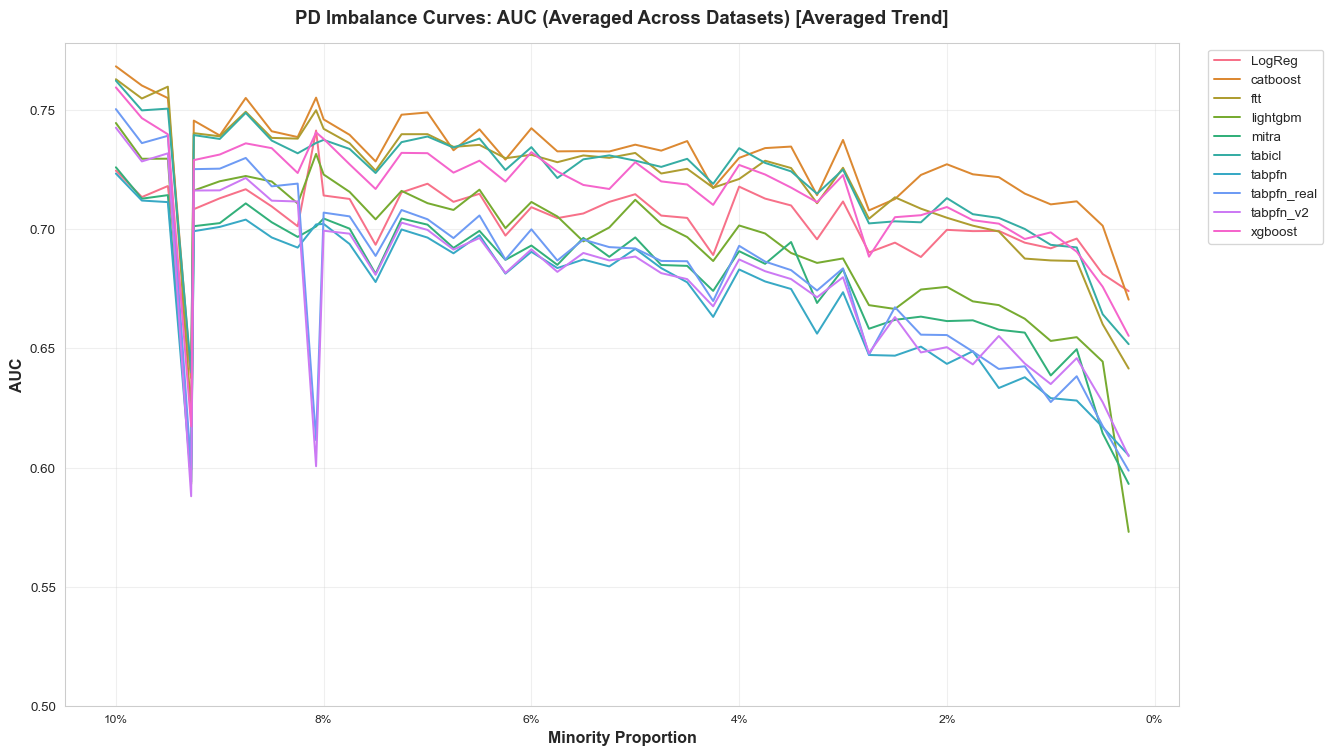


PD F1 Imbalance Curves [Averaged Trend]
Saved: pd_imbalance_curve_f1_averaged.png


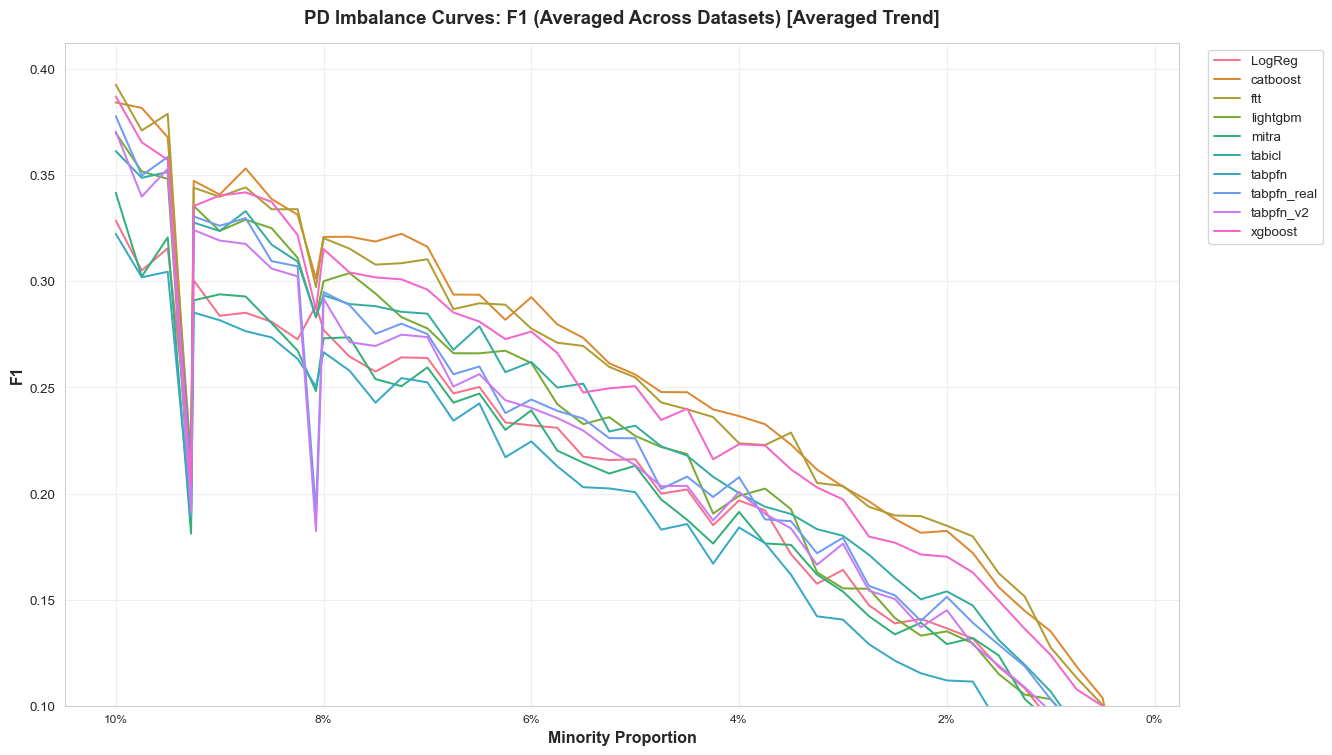


PD Relative Performance Decay [Averaged Trend]
Saved: pd_relative_performance_auc_averaged.png


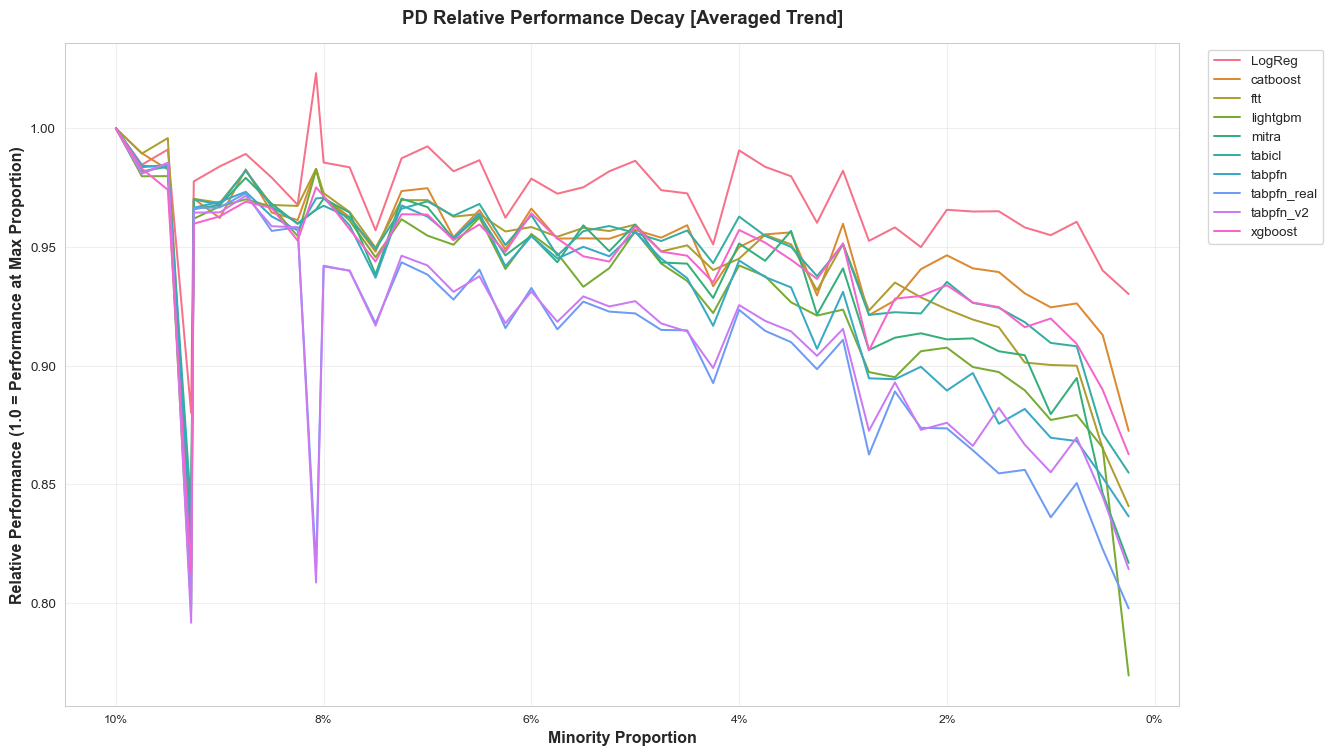


PD Degradation Analysis
Saved: pd_degradation_auc.png


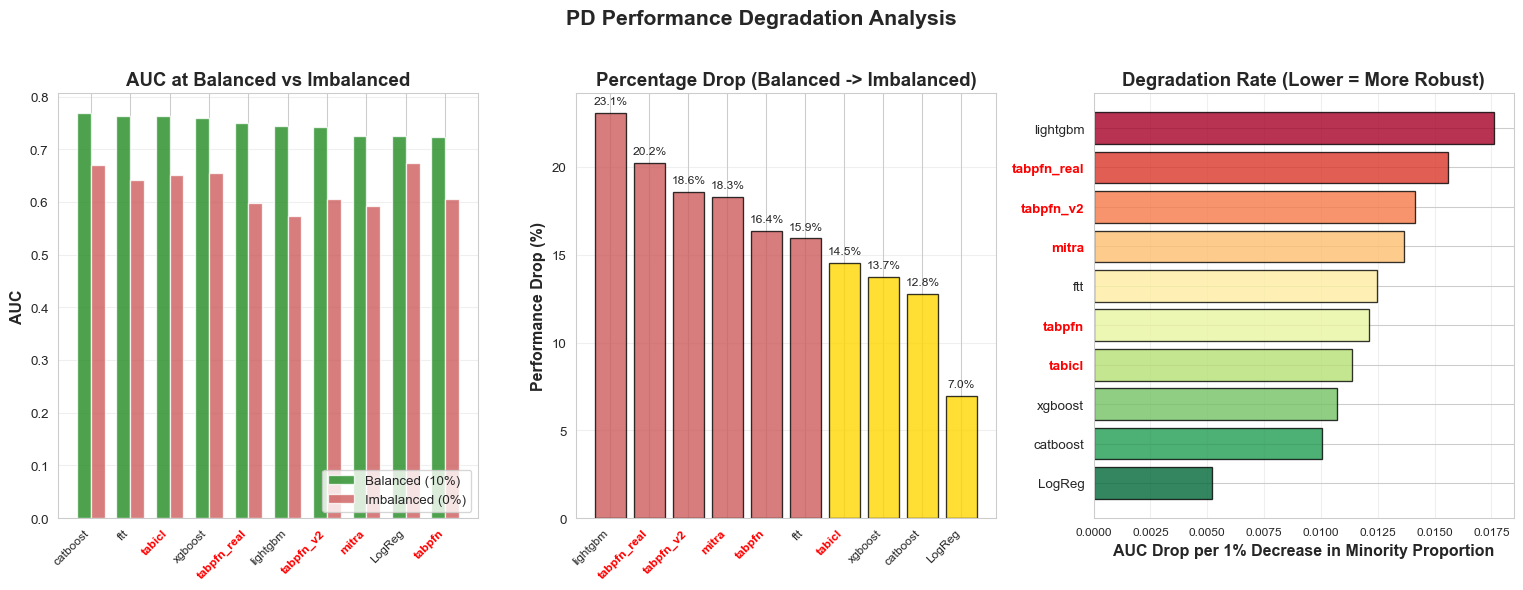


PD AUC Difference: tabpfn_v2 - xgboost [Averaged Across Datasets]
Saved: pd_tabpfnv2_vs_xgboost_diff.png


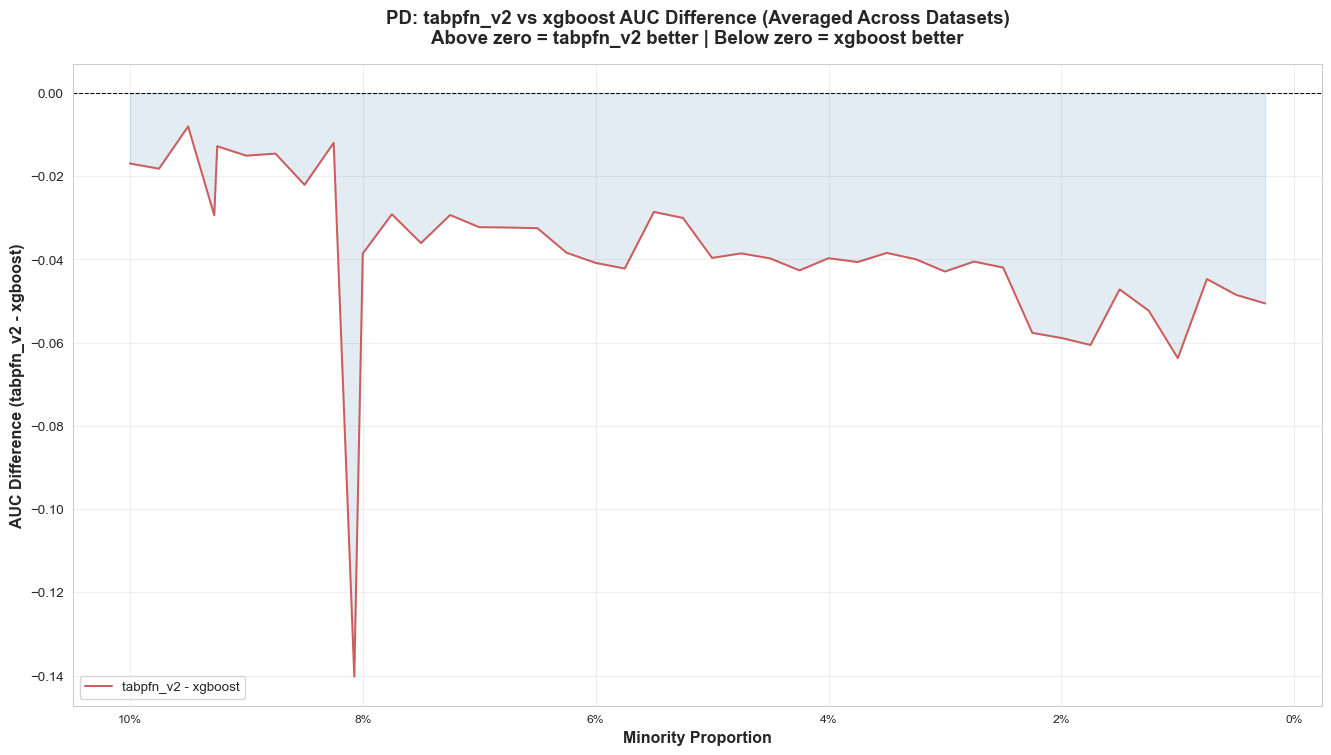

In [12]:
if has_pd and not pd_agg.empty:
    # Averaged AUC imbalance curve (smooth trend, no dots)
    print("PD AUC Imbalance Curves [Averaged Trend]")
    plot_imbalance_curves(pd_agg, 'AUC', 'PD', averaged=True, y_min=0.5)
    plt.show()
    
    # Averaged F1 imbalance curve
    print("\nPD F1 Imbalance Curves [Averaged Trend]")
    plot_imbalance_curves(pd_agg, 'F1', 'PD', averaged=True, y_min=0.1)
    plt.show()
    
    # Averaged Relative Performance Decay
    print("\nPD Relative Performance Decay [Averaged Trend]")
    plot_relative_performance(pd_agg, 'AUC', 'PD', averaged=True)
    plt.show()
    
    # Degradation bar charts
    print("\nPD Degradation Analysis")
    plot_degradation_analysis(pd_degradation, 'AUC', 'PD')
    plt.show()

    # === tabpfn_v2 vs xgboost AUC difference across minority proportions ===
    print("\nPD AUC Difference: tabpfn_v2 - xgboost [Averaged Across Datasets]")
    mean_col = 'AUC_mean'
    avg_df = pd_agg.groupby(['method', 'minority_proportion'])[mean_col].mean().reset_index()

    tfn = avg_df[avg_df['method'] == 'tabpfn_v2'].sort_values('minority_proportion').set_index('minority_proportion')[mean_col]
    xgb = avg_df[avg_df['method'] == 'xgboost'].sort_values('minority_proportion').set_index('minority_proportion')[mean_col]

    if not tfn.empty and not xgb.empty:
        common_props = sorted(set(tfn.index) & set(xgb.index))
        if common_props:
            diff = tfn.loc[common_props] - xgb.loc[common_props]

            fig, ax = plt.subplots(figsize=(14, 8))
            ax.plot(common_props, diff.values, '-', color='indianred', linewidth=LINE_WIDTH_THICK,
                    label='tabpfn_v2 - xgboost')
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
            ax.fill_between(common_props, diff.values, 0, where=[d > 0 for d in diff.values],
                            color='indianred', alpha=0.15, interpolate=True)
            ax.fill_between(common_props, diff.values, 0, where=[d <= 0 for d in diff.values],
                            color='steelblue', alpha=0.15, interpolate=True)
            ax.set_xlabel('Minority Proportion', fontsize=12, fontweight='bold')
            ax.set_ylabel('AUC Difference (tabpfn_v2 - xgboost)', fontsize=12, fontweight='bold')
            ax.set_title('PD: tabpfn_v2 vs xgboost AUC Difference (Averaged Across Datasets)\n'
                         'Above zero = tabpfn_v2 better | Below zero = xgboost better',
                         fontsize=14, fontweight='bold', pad=15)
            ax.invert_xaxis()
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            filename = FIGURES_DIR / "pd_tabpfnv2_vs_xgboost_diff.png"
            plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
            print(f"Saved: {filename.name}")
            plt.show()

### A1.3 Key Methods Comparison (Averaged)

PD AUC Imbalance Curves - Key Methods [Averaged Trend]
Saved: pd_imbalance_curve_auc_averaged_key.png


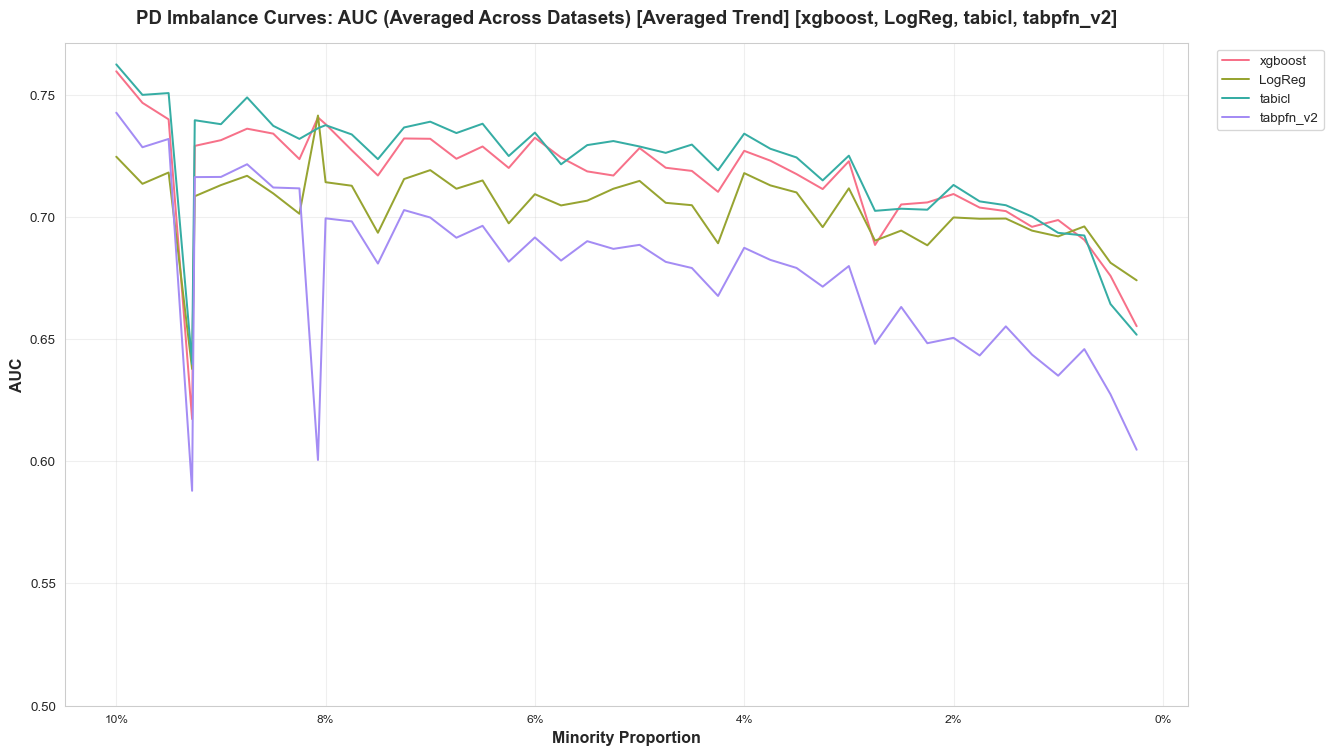


PD F1 Imbalance Curves - Key Methods [Averaged Trend]
Saved: pd_imbalance_curve_f1_averaged_key.png


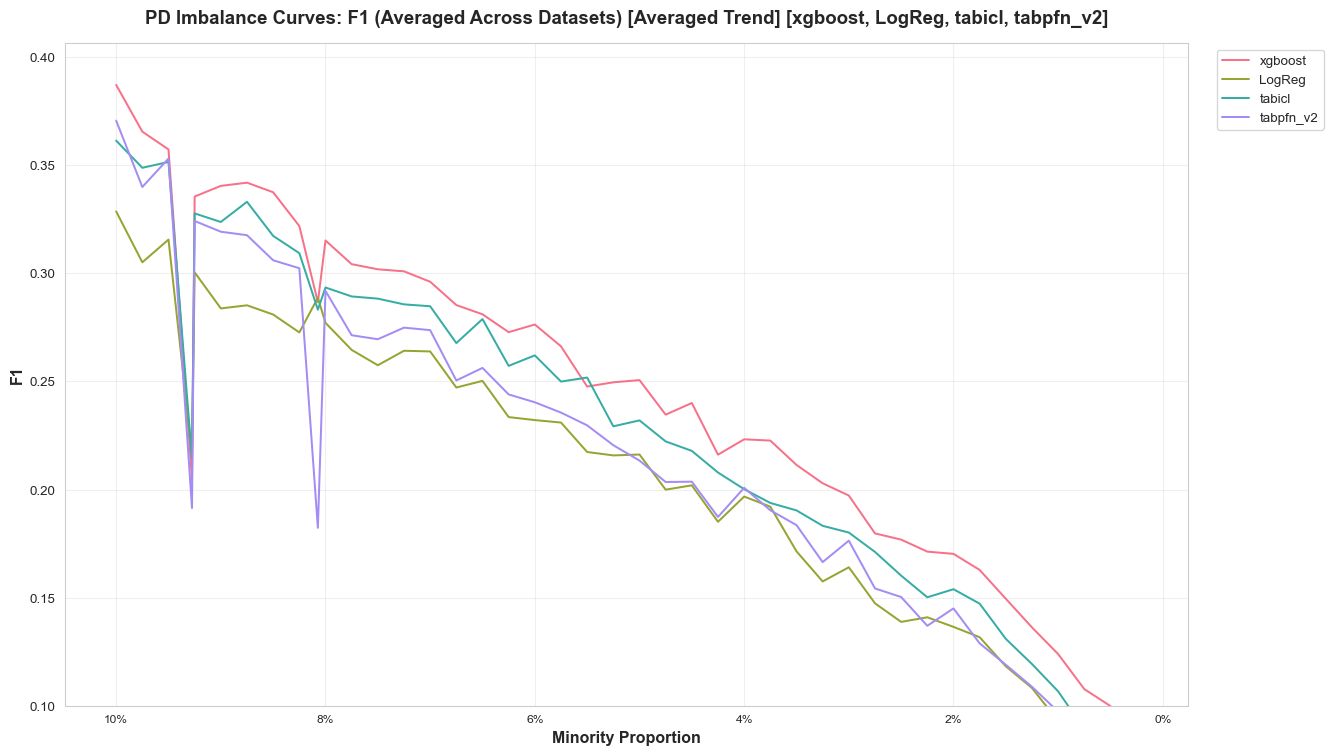


PD Relative Performance Decay - Key Methods [Averaged Trend]
Saved: pd_relative_performance_auc_averaged.png


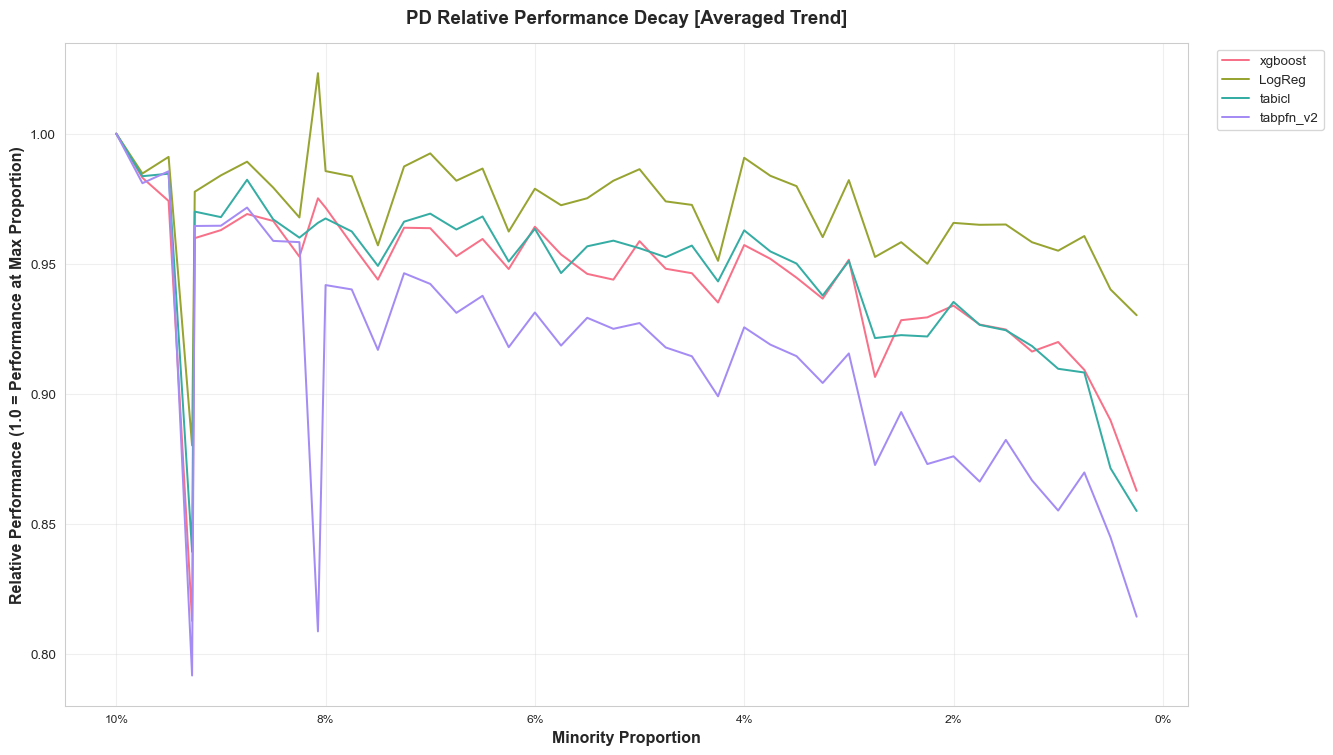

In [13]:
if has_pd and not pd_agg.empty:
    # Key methods AUC (averaged)
    print("PD AUC Imbalance Curves - Key Methods [Averaged Trend]")
    plot_imbalance_curves(pd_agg, 'AUC', 'PD', methods=PD_KEY_METHODS, averaged=True, y_min=0.5)
    plt.show()
    
    # Key methods F1 (averaged)
    print("\nPD F1 Imbalance Curves - Key Methods [Averaged Trend]")
    plot_imbalance_curves(pd_agg, 'F1', 'PD', methods=PD_KEY_METHODS, averaged=True, y_min=0.1)
    plt.show()
    
    # Key methods Relative Performance Decay (averaged)
    print("\nPD Relative Performance Decay - Key Methods [Averaged Trend]")
    plot_relative_performance(pd_agg, 'AUC', 'PD', methods=PD_KEY_METHODS, averaged=True)
    plt.show()

## A2. Rank Analysis

PD Rank Evolution [Averaged Trend]
Saved: pd_rank_evolution_auc_averaged.png


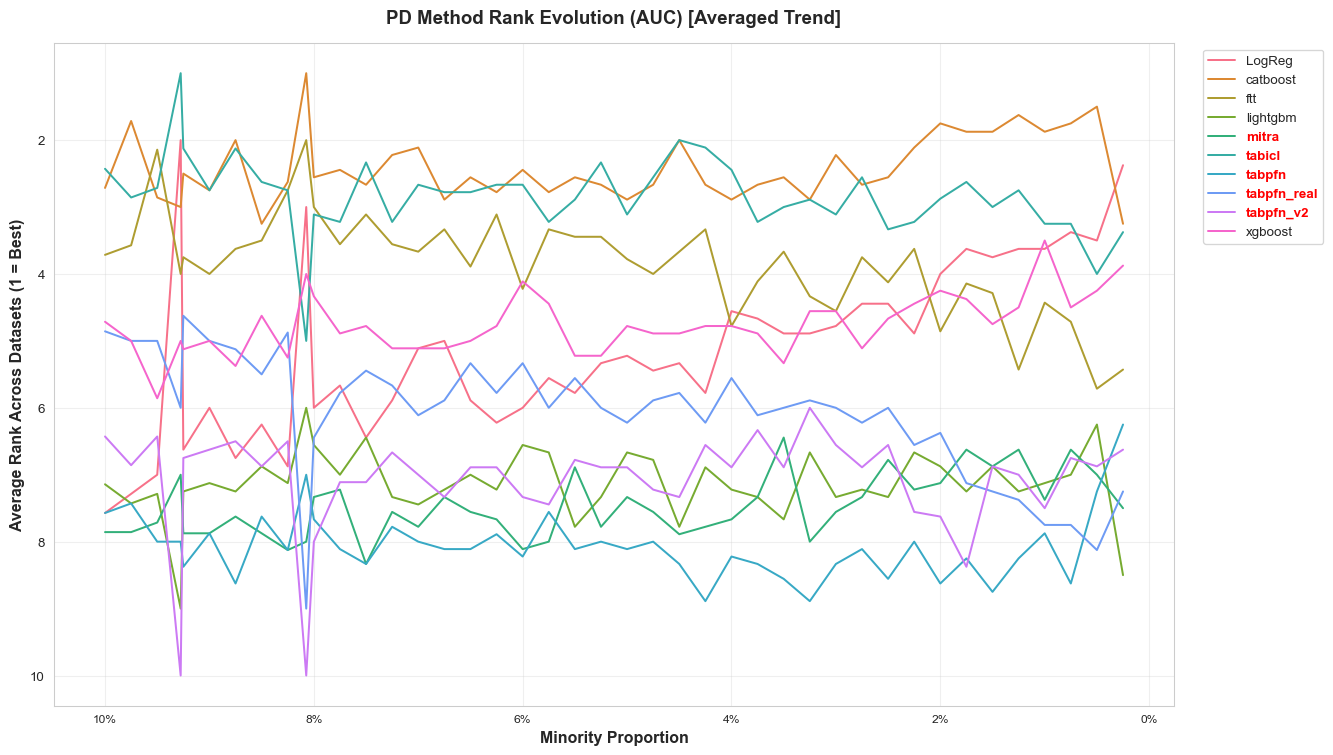


PD Rank Evolution - Key Methods [Averaged Trend]
Saved: pd_rank_evolution_auc_averaged_key.png


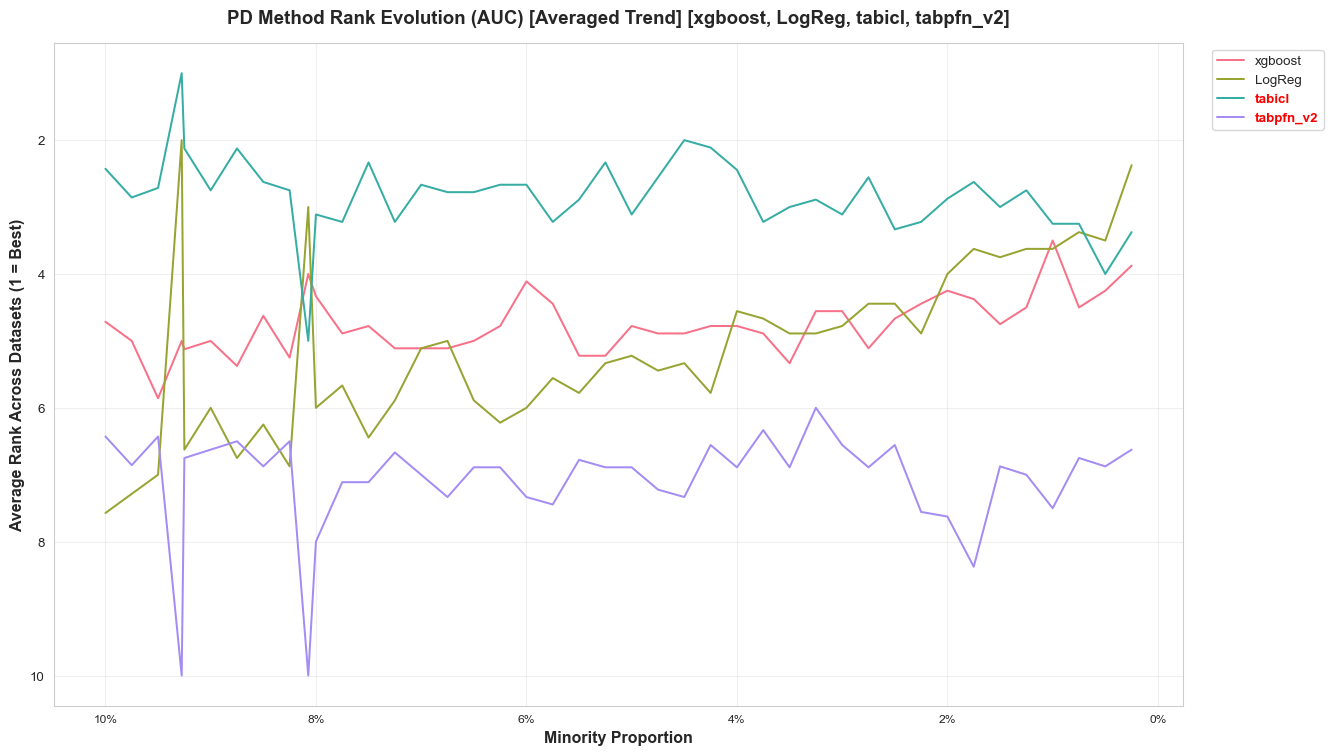


PD Spearman Rank Correlation
Saved: pd_spearman_rank_auc.png


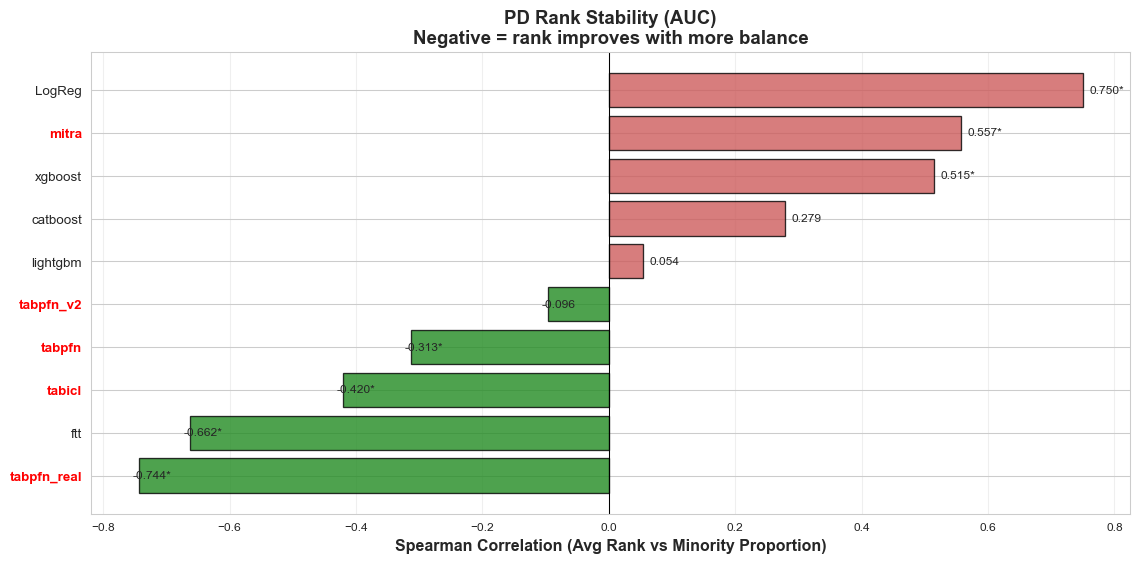


PD Performance Scaling (Pearson)
Saved: pd_pearson_metric_auc.png


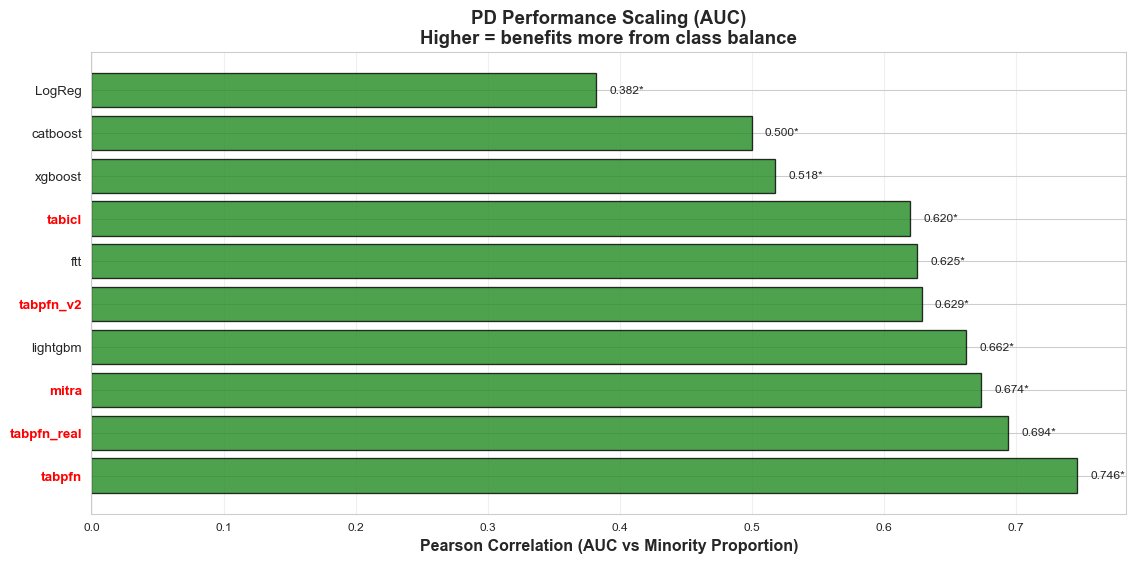

In [14]:
if has_pd and not pd_agg.empty:
    # Rank evolution across minority proportions (all methods, averaged trend)
    print("PD Rank Evolution [Averaged Trend]")
    plot_rank_evolution(pd_agg, 'AUC', 'PD', averaged=True)
    plt.show()
    
    # Rank evolution - key methods only (averaged trend)
    print("\nPD Rank Evolution - Key Methods [Averaged Trend]")
    plot_rank_evolution(pd_agg, 'AUC', 'PD', methods=PD_KEY_METHODS, averaged=True)
    plt.show()
    
    # Spearman rank correlation
    print("\nPD Spearman Rank Correlation")
    plot_spearman_rank_correlation(pd_agg, 'AUC', 'PD')
    plt.show()
    
    # Pearson AUC vs minority_proportion correlation
    print("\nPD Performance Scaling (Pearson)")
    plot_metric_vs_proportion_correlation(pd_agg, 'AUC', 'PD')
    plt.show()

## A3. Per-Dataset Analysis

Generating per-dataset imbalance curves for 9 PD datasets...

Dataset: 0002.taiwan_creditcard
Saved: pd_imbalance_curve_auc_0002_taiwan_creditcard_averaged.png


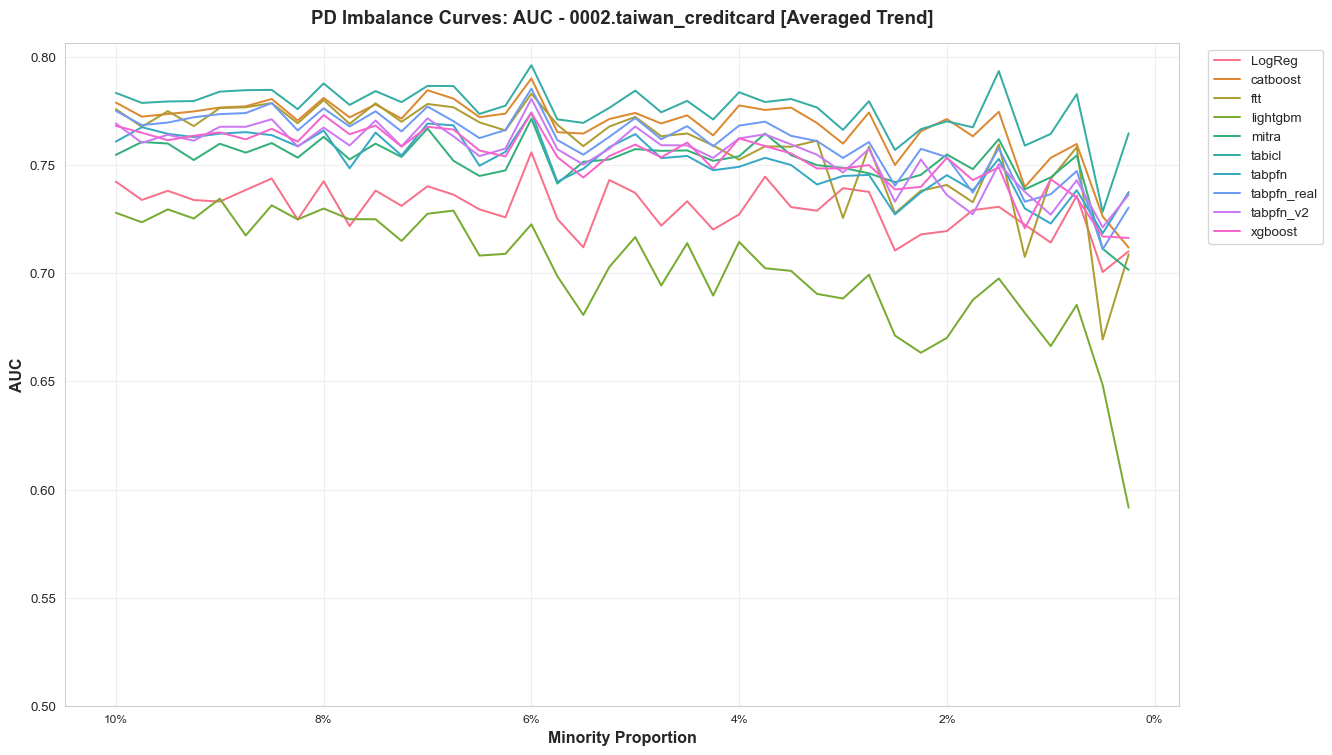

Saved: pd_imbalance_curve_auc_0002_taiwan_creditcard_averaged_key.png


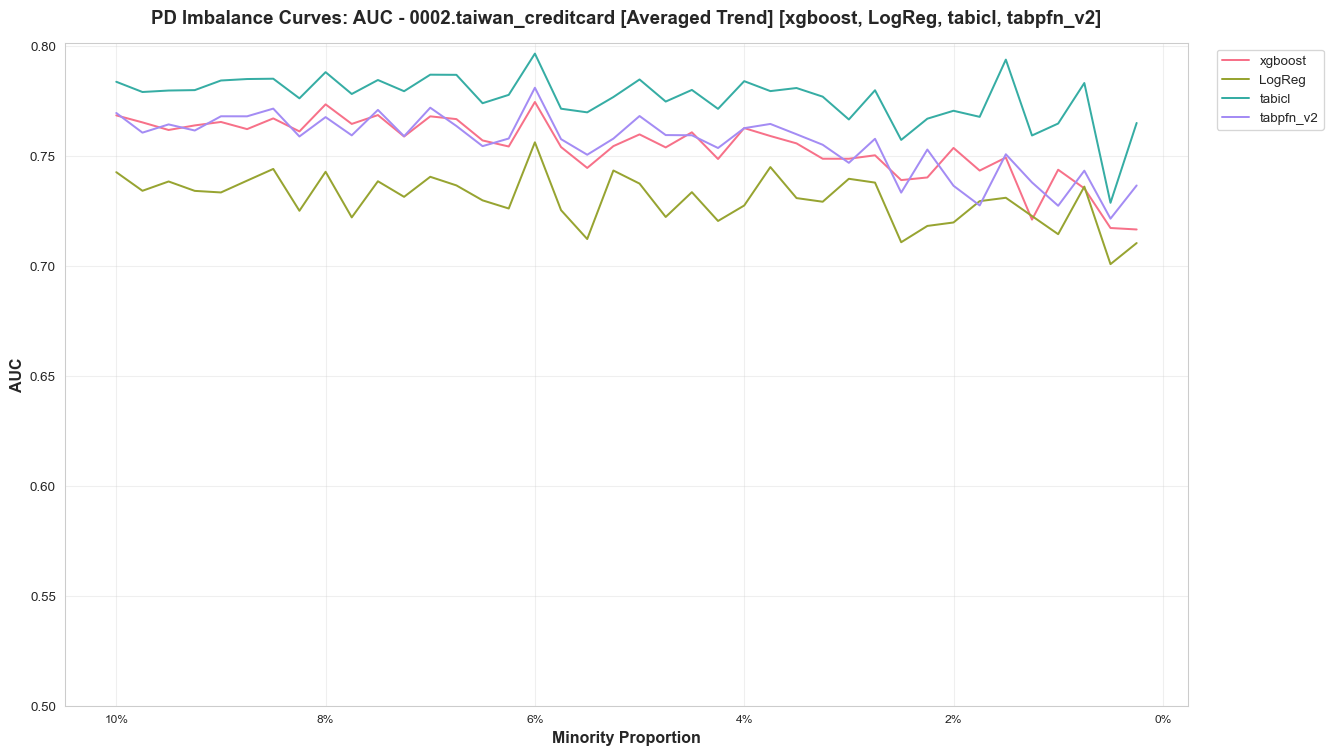

Dataset: 0003.vehicle_loan
Saved: pd_imbalance_curve_auc_0003_vehicle_loan_averaged.png


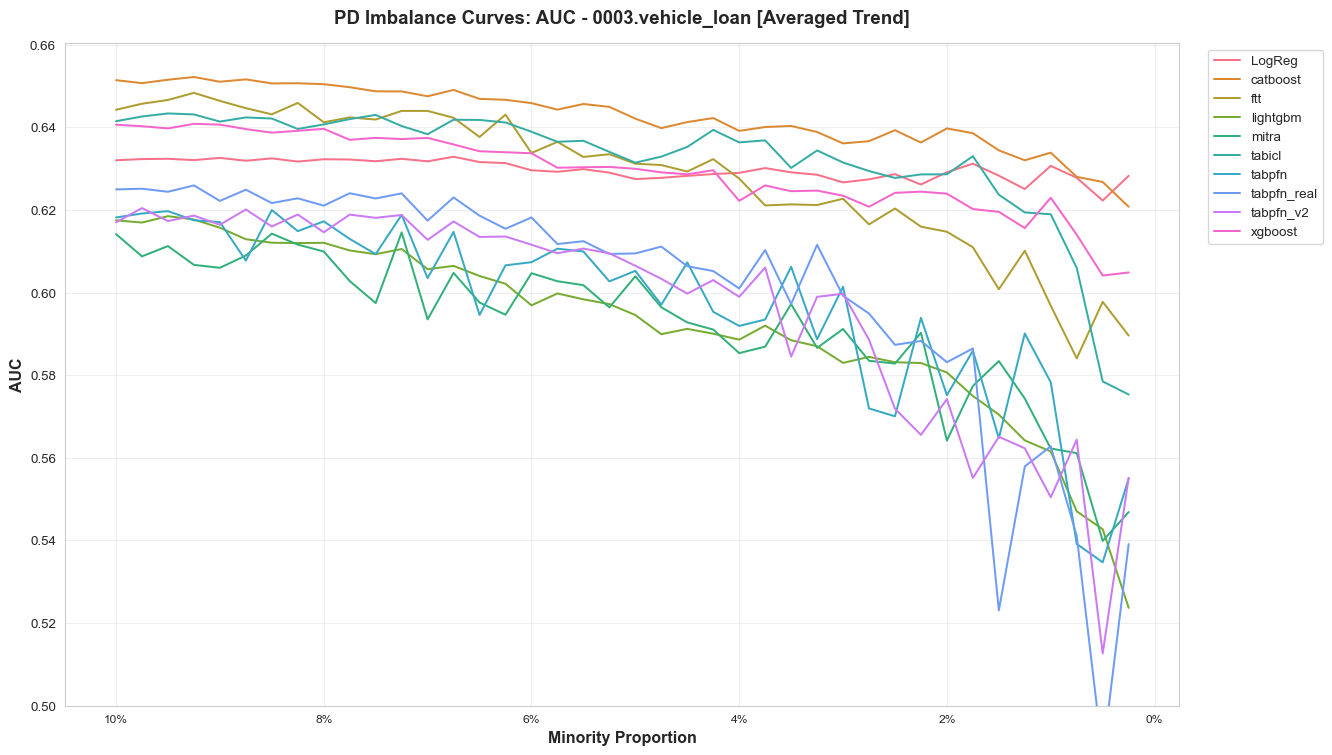

Saved: pd_imbalance_curve_auc_0003_vehicle_loan_averaged_key.png


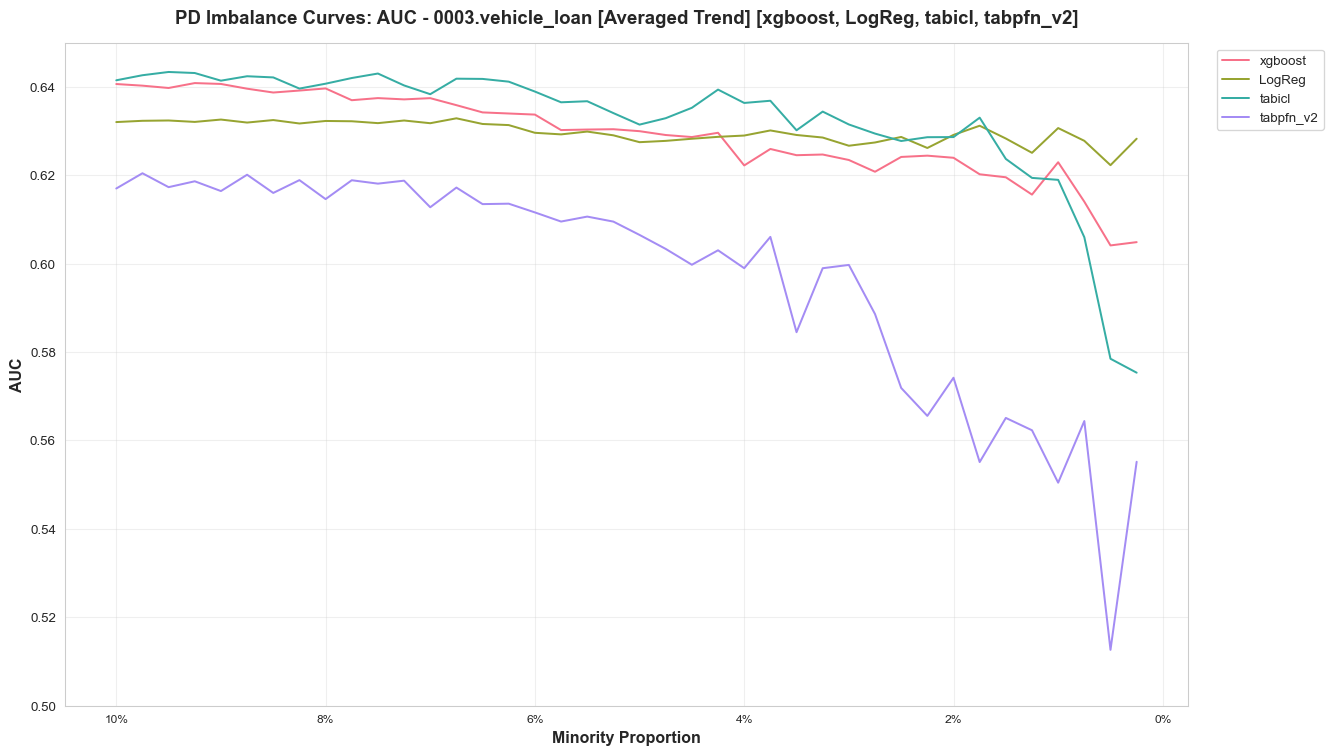

Dataset: 0006.hackerearth
Saved: pd_imbalance_curve_auc_0006_hackerearth_averaged.png


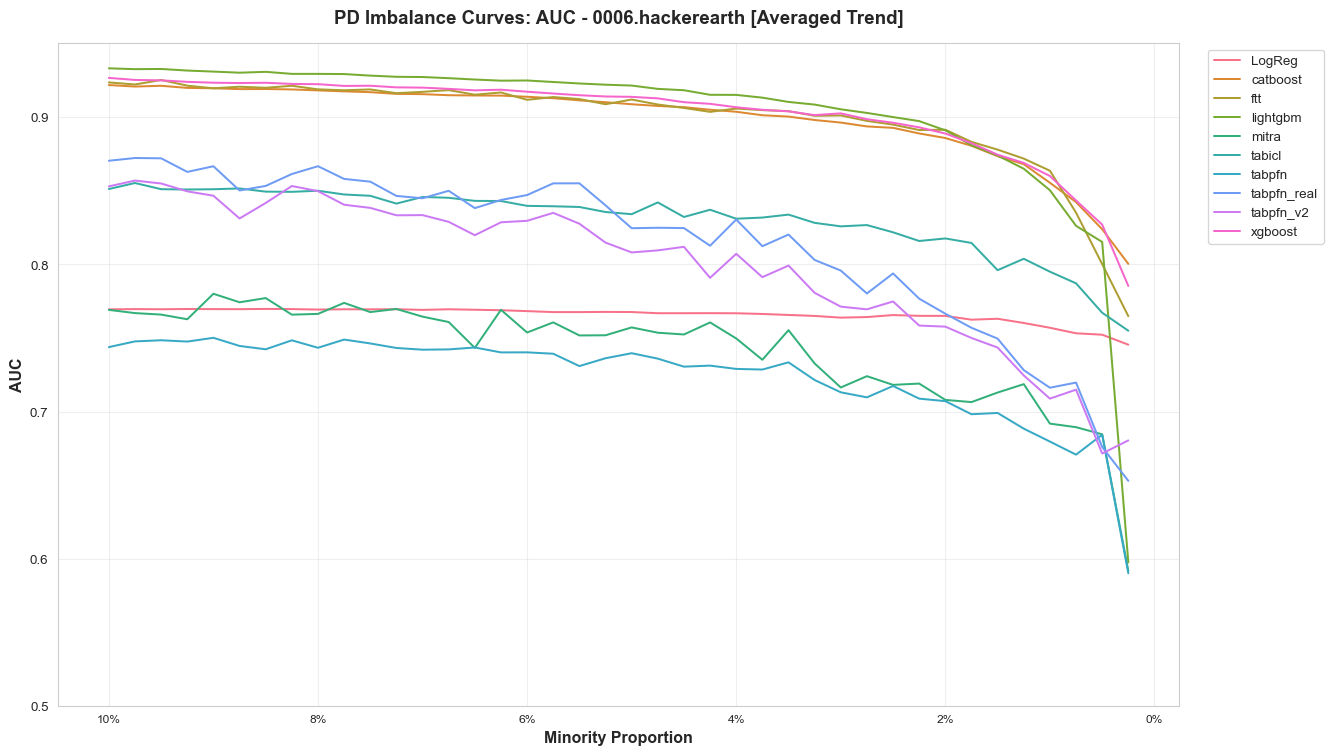

Saved: pd_imbalance_curve_auc_0006_hackerearth_averaged_key.png


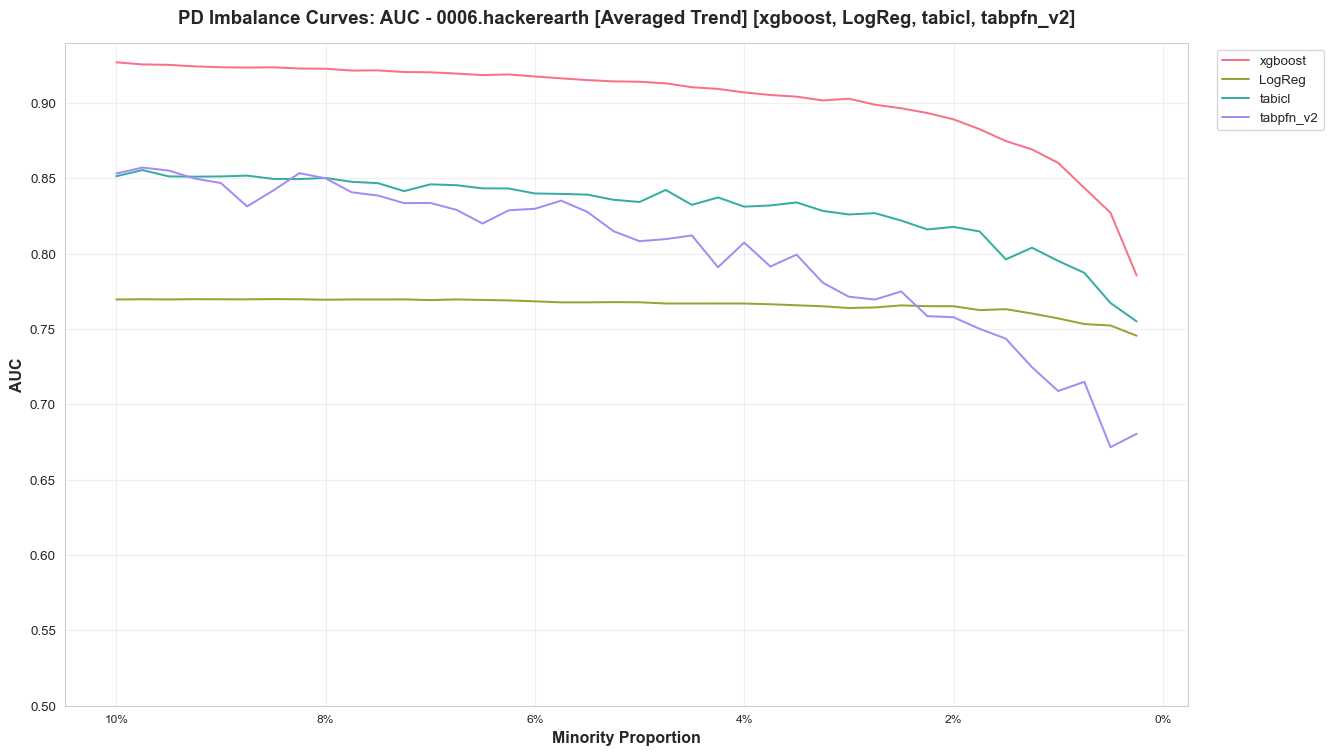

Dataset: 0007.cobranded
Saved: pd_imbalance_curve_auc_0007_cobranded_averaged.png


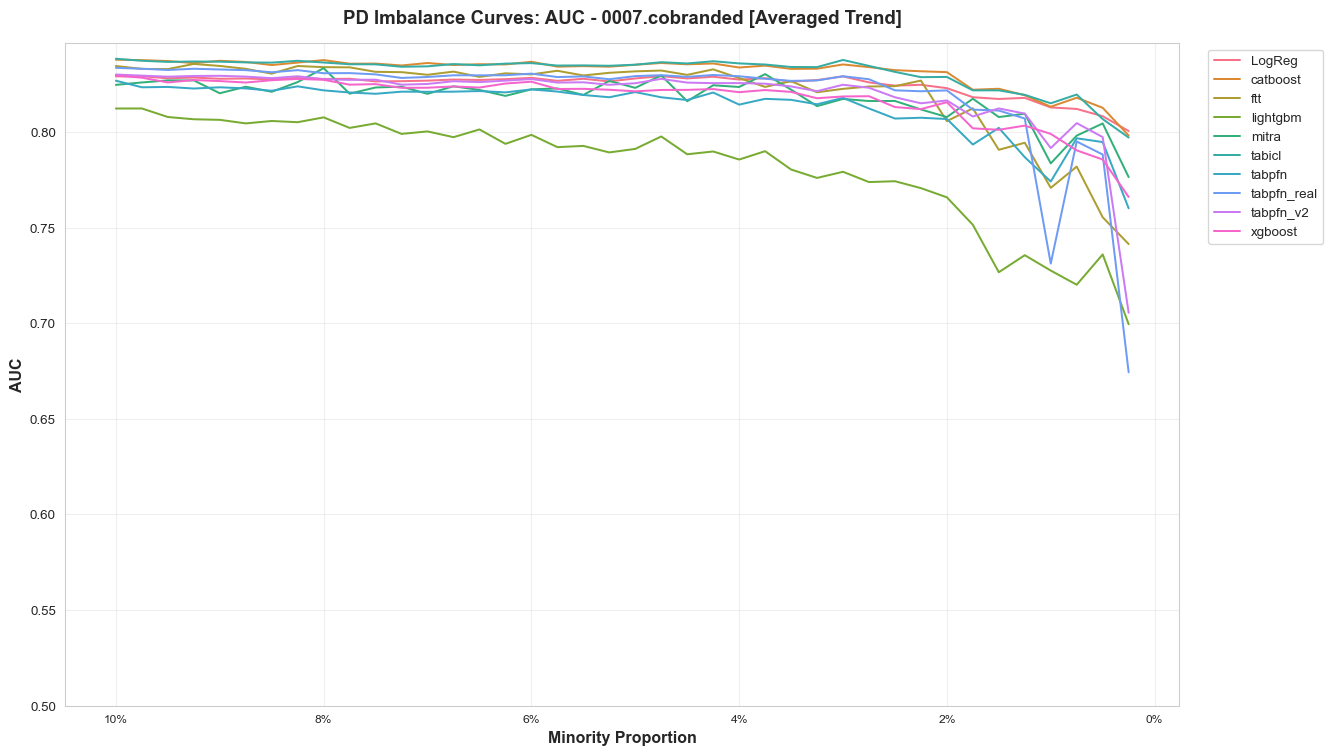

Saved: pd_imbalance_curve_auc_0007_cobranded_averaged_key.png


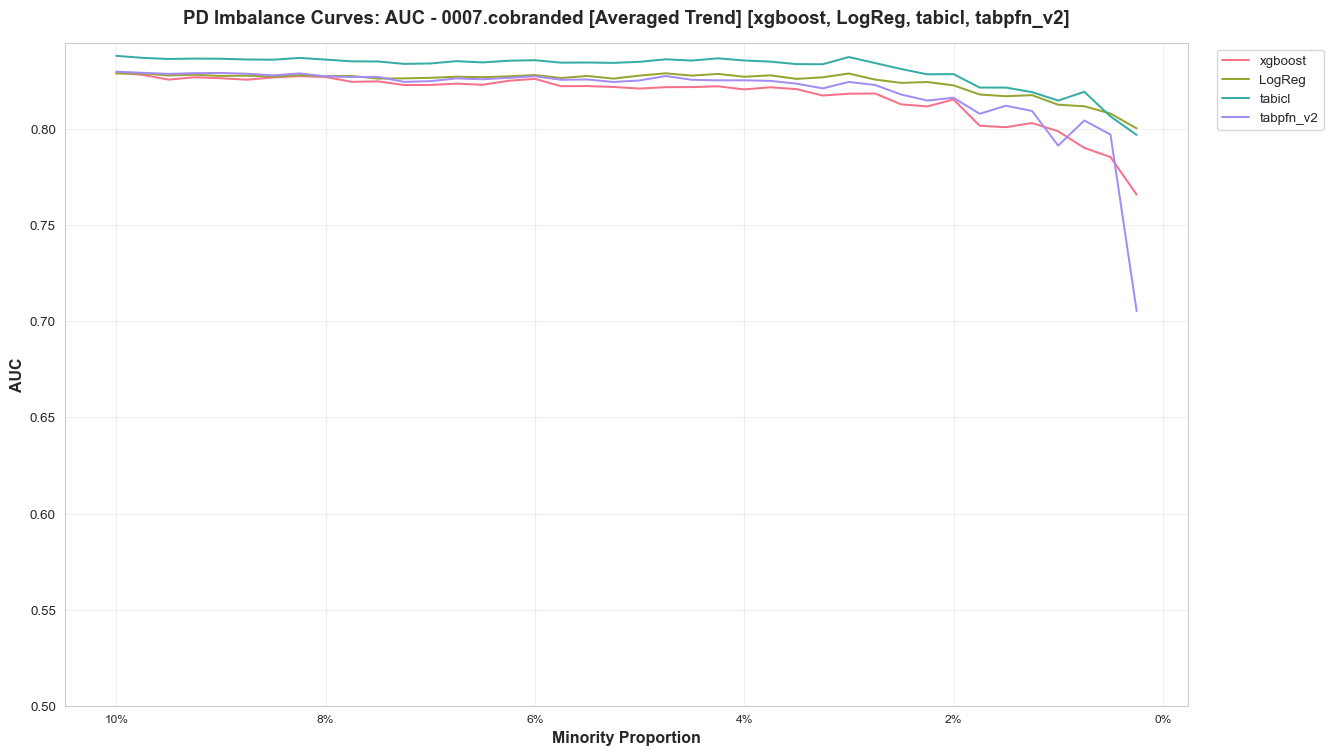

Dataset: 0008.german
Saved: pd_imbalance_curve_auc_0008_german_averaged.png


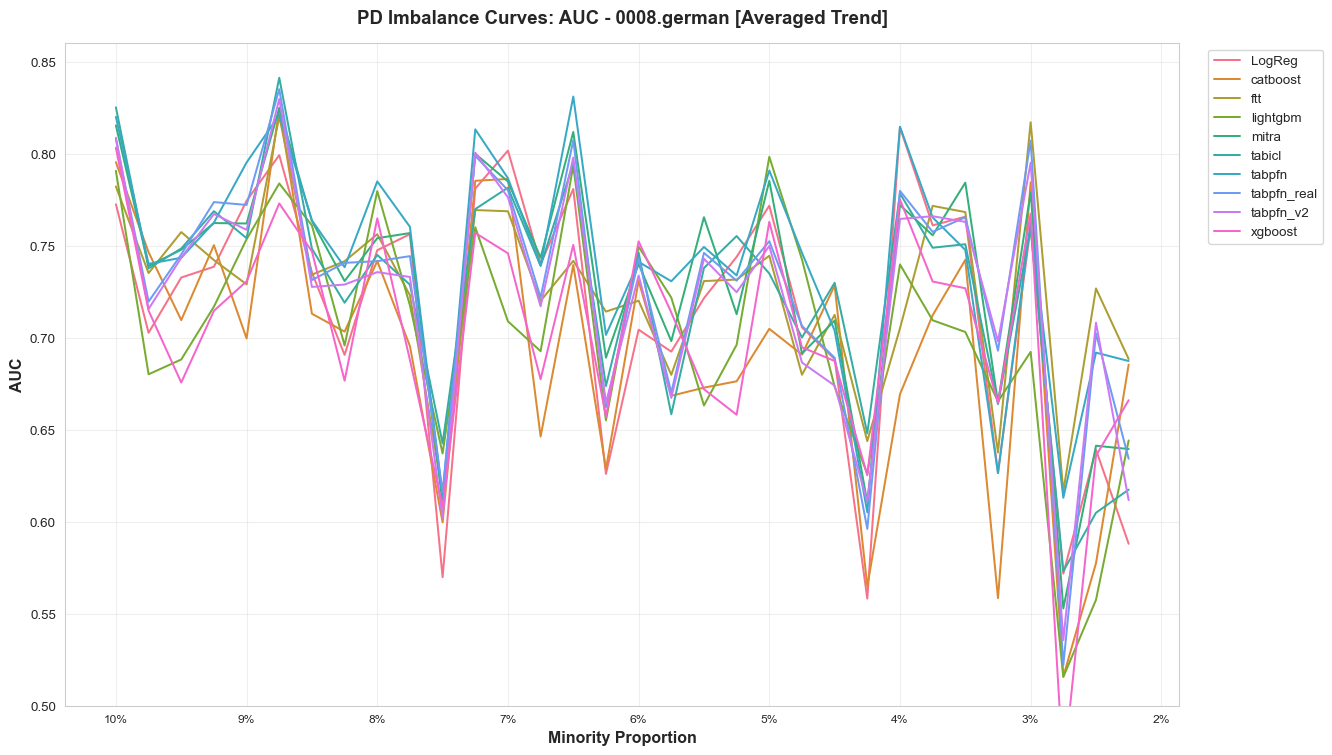

Saved: pd_imbalance_curve_auc_0008_german_averaged_key.png


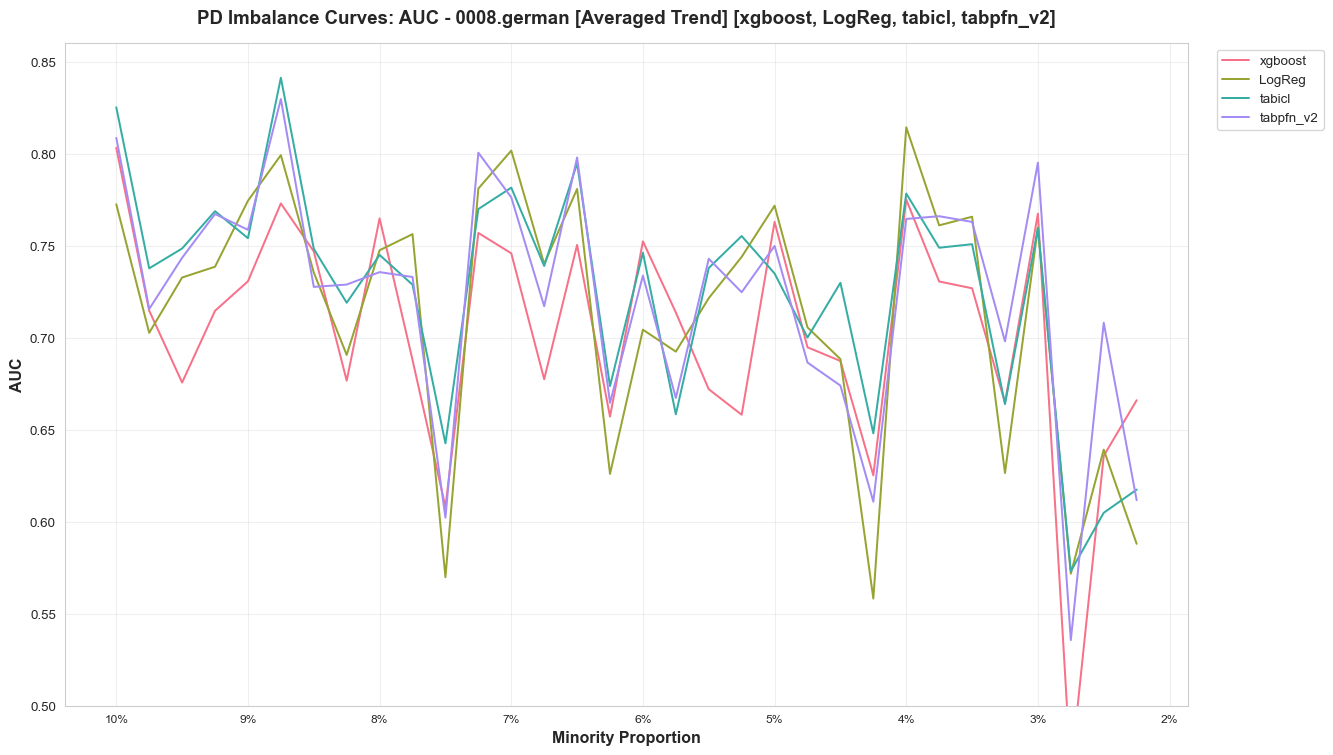

Dataset: 0009.bank_status
Saved: pd_imbalance_curve_auc_0009_bank_status_averaged.png


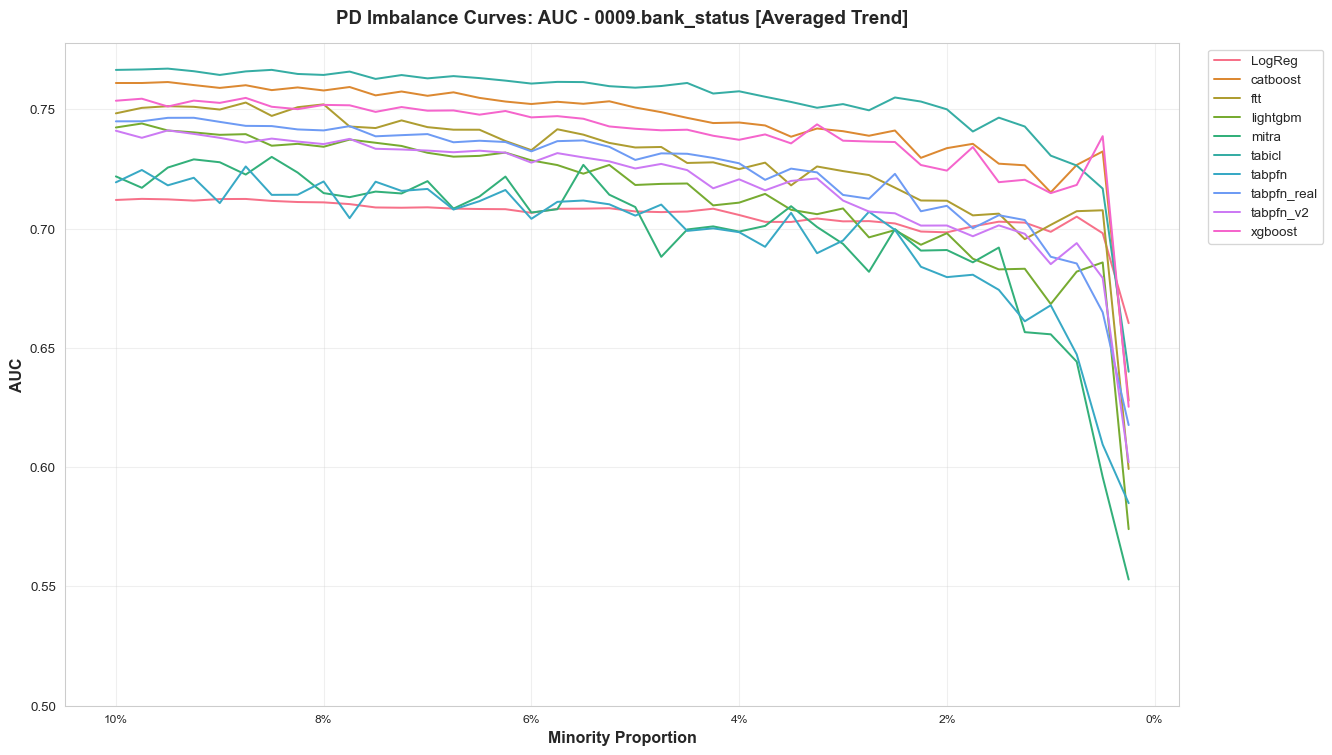

Saved: pd_imbalance_curve_auc_0009_bank_status_averaged_key.png


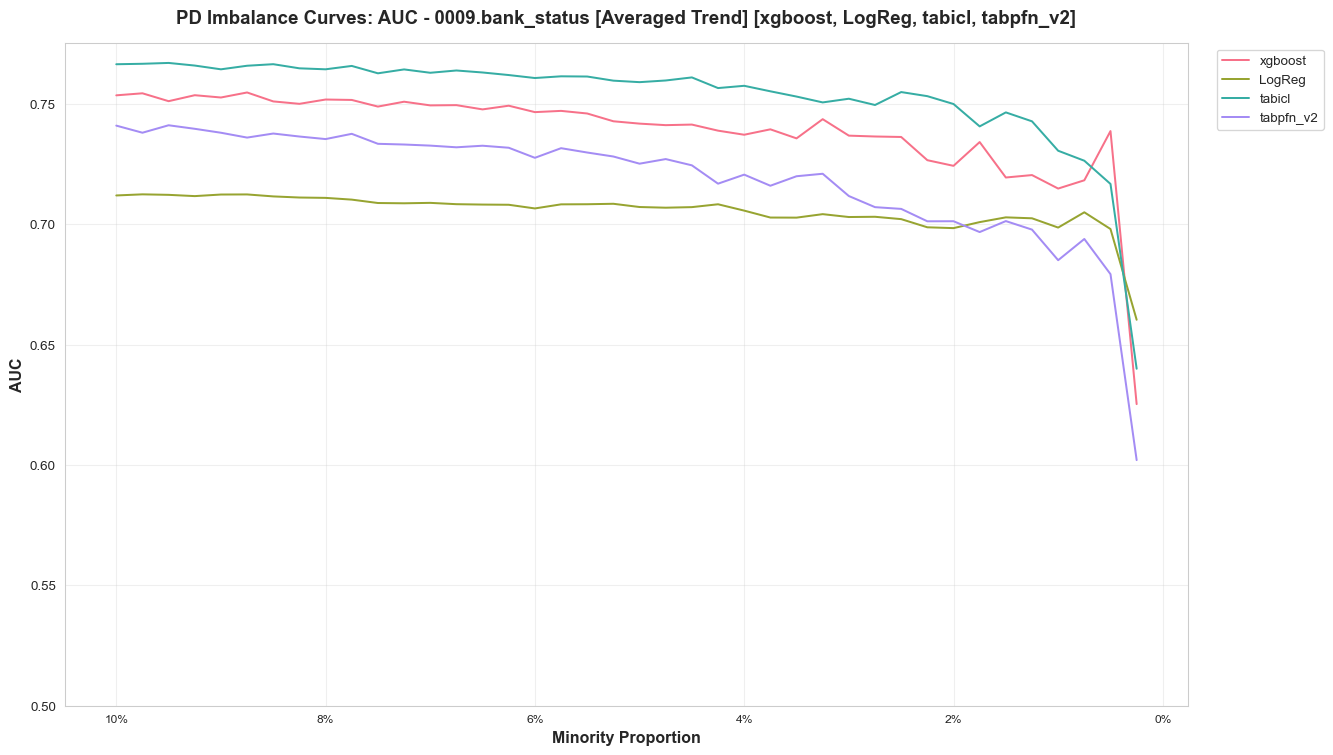

Dataset: 0011.loan_default
Saved: pd_imbalance_curve_auc_0011_loan_default_averaged.png


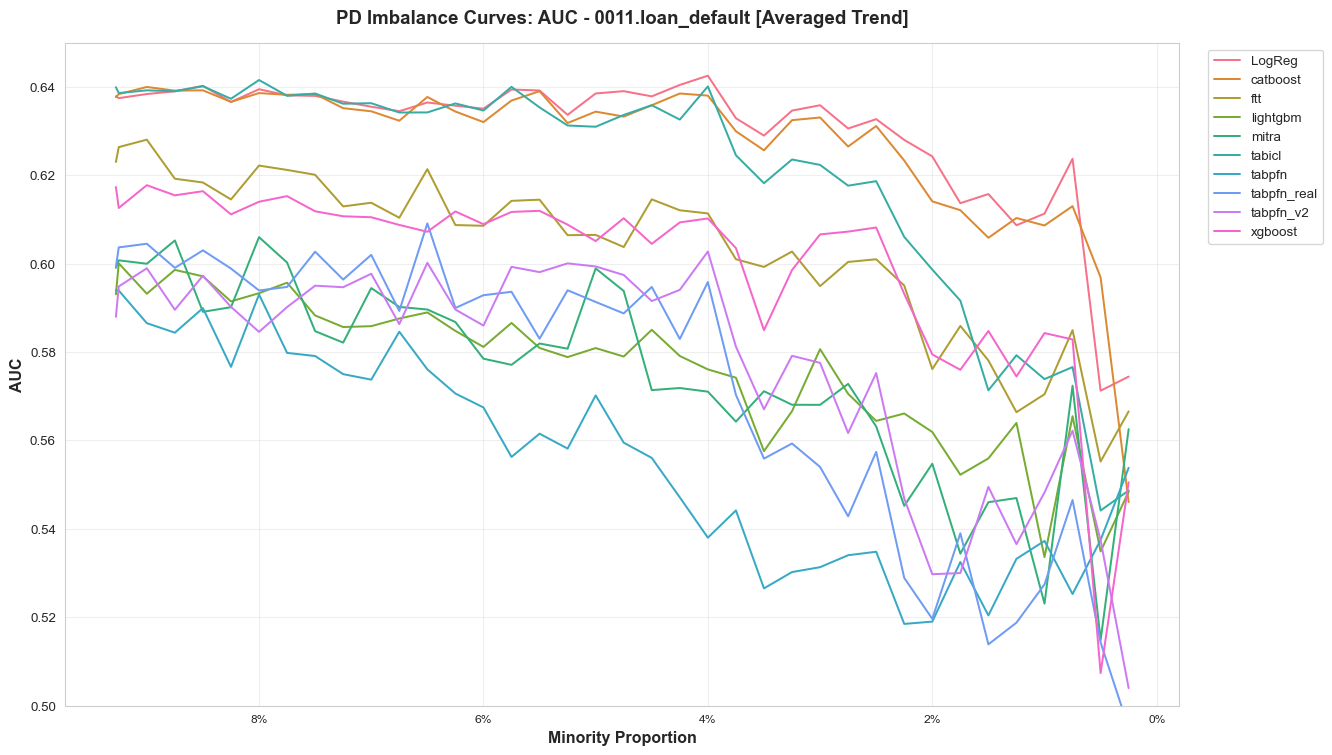

Saved: pd_imbalance_curve_auc_0011_loan_default_averaged_key.png


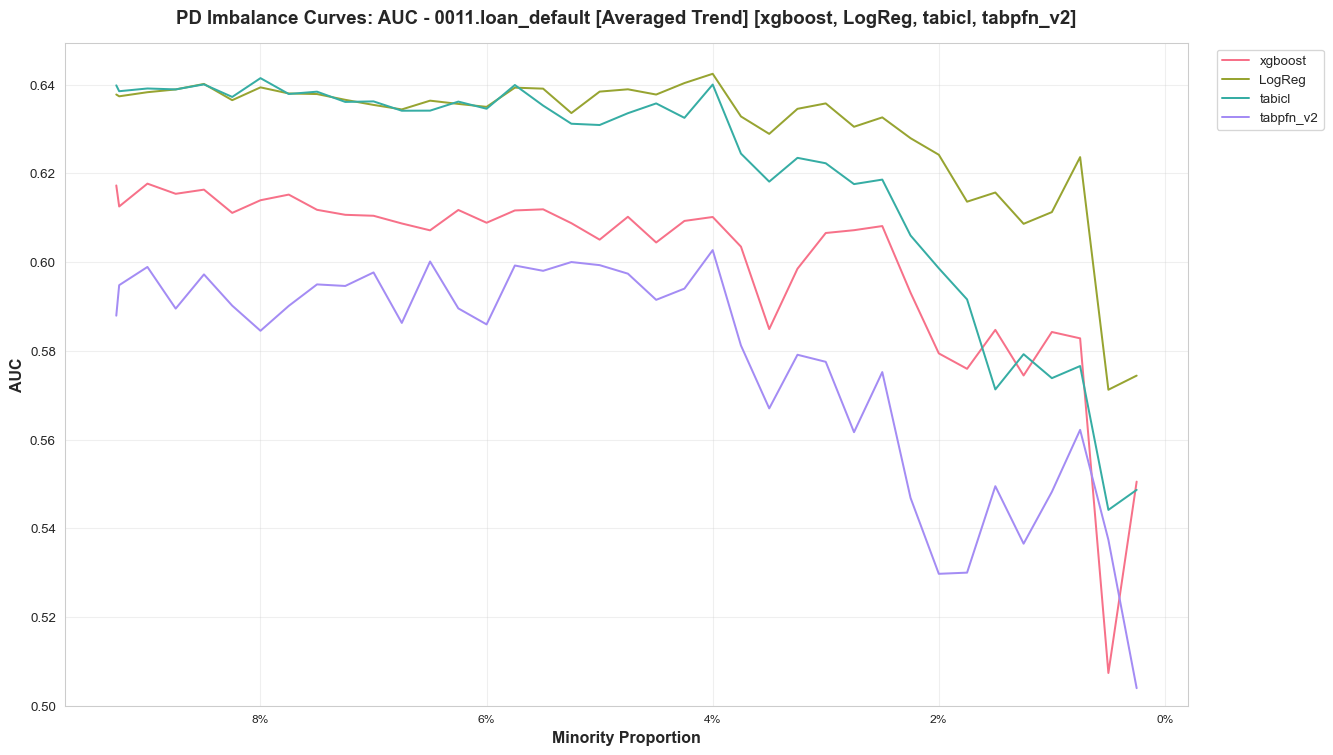

Dataset: 0012.home_credit
Saved: pd_imbalance_curve_auc_0012_home_credit_averaged.png


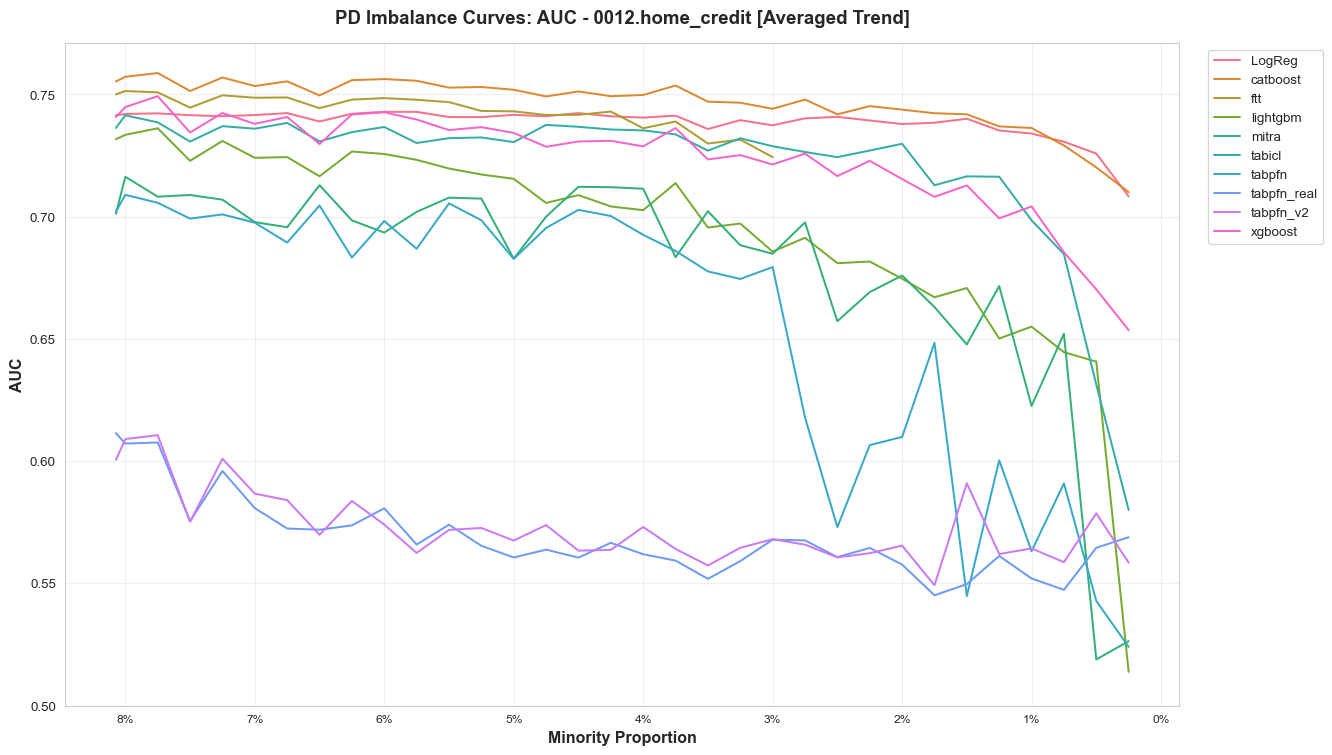

Saved: pd_imbalance_curve_auc_0012_home_credit_averaged_key.png


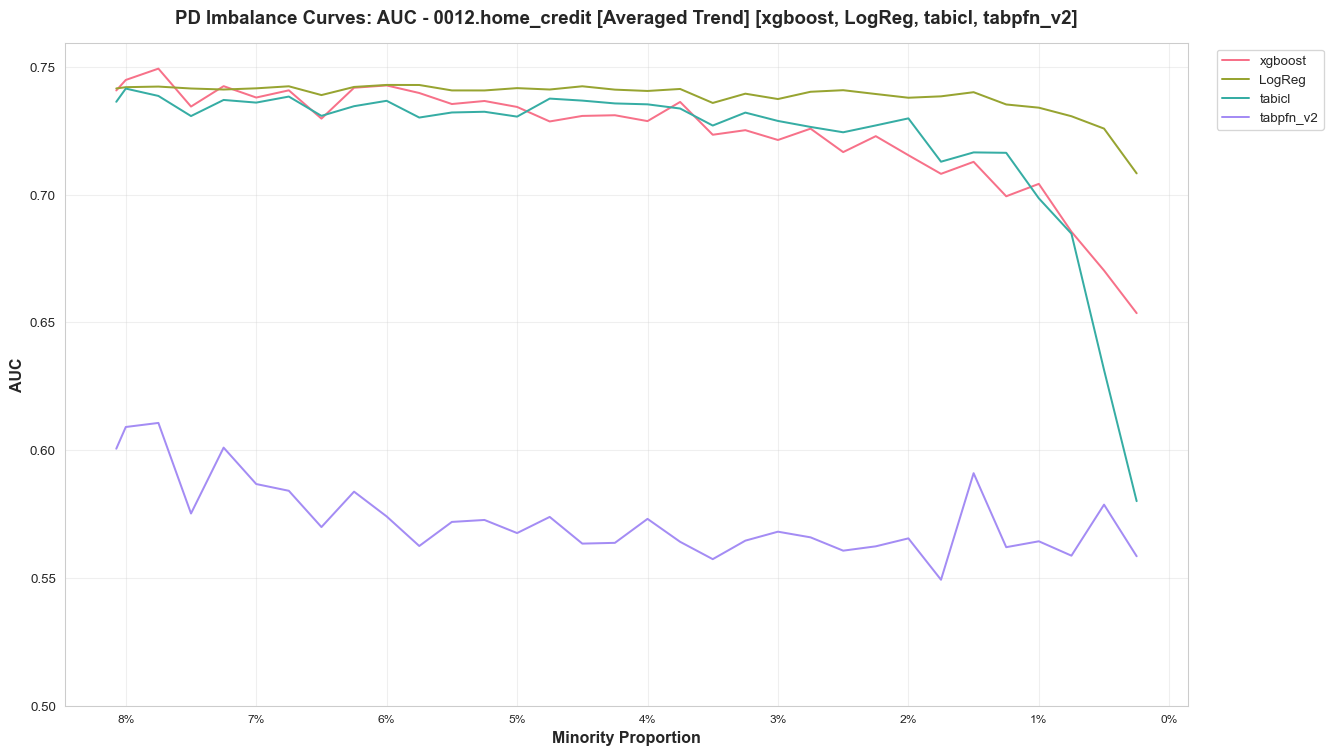

Dataset: 0014.algorithmwatch
Saved: pd_imbalance_curve_auc_0014_algorithmwatch_averaged.png


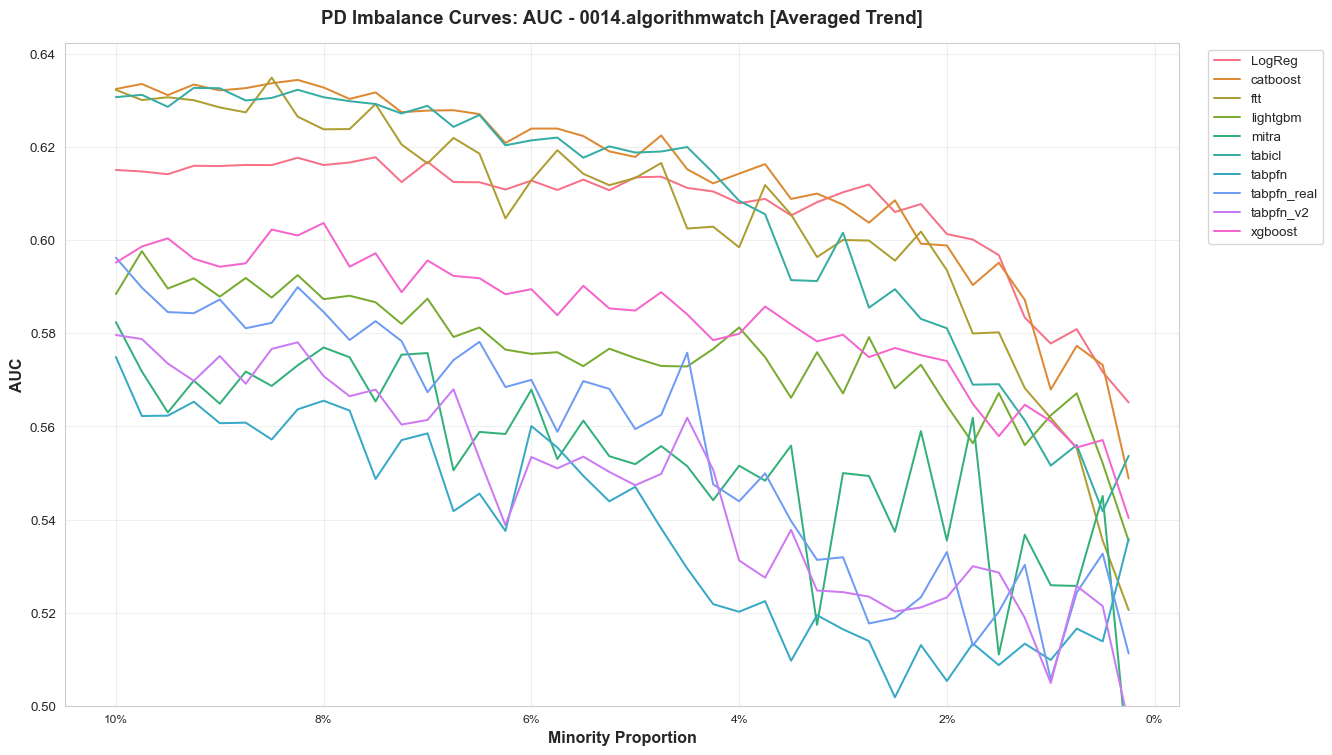

Saved: pd_imbalance_curve_auc_0014_algorithmwatch_averaged_key.png


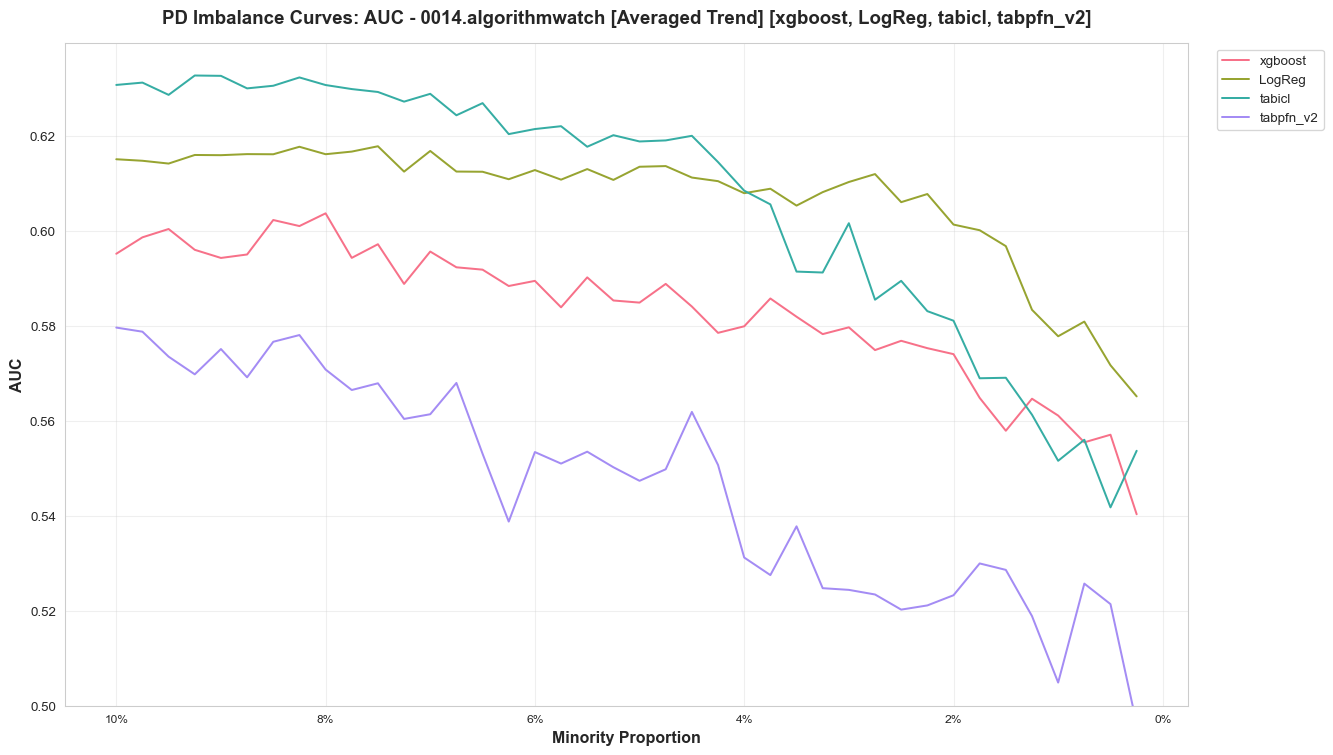

In [15]:
if has_pd and not pd_agg.empty:
    datasets = sorted(pd_agg['dataset'].unique())
    print(f"Generating per-dataset imbalance curves for {len(datasets)} PD datasets...\n")
    
    for dataset in datasets:
        print(f"{'='*60}")
        print(f"Dataset: {dataset}")
        print(f"{'='*60}")
        
        # All methods (averaged trend)
        plot_imbalance_curves(pd_agg, 'AUC', 'PD', dataset=dataset, averaged=True, y_min=0.5)
        plt.show()
        
        # Key methods only (averaged trend)
        plot_imbalance_curves(pd_agg, 'AUC', 'PD', methods=PD_KEY_METHODS, dataset=dataset, averaged=True, y_min=0.5)
        plt.show()